# Nutrition Analysis and Modelling: District-Level Malnutrition in India

## Project Overview

Child malnutrition remains one of India's most pressing public health challenges. Despite decades of economic growth, rates of stunting, wasting, underweight, and anaemia remain stubbornly high — and they vary dramatically across districts. This notebook investigates **why** some districts perform far worse than others by linking nutrition outcomes to structural determinants such as sanitation, education, healthcare access, and agricultural productivity.

### Research Questions
1. How are malnutrition indicators distributed across Indian districts, and which outcomes show the greatest disparity?
2. Which socioeconomic and infrastructure variables are the strongest predictors of poor nutrition outcomes?
3. Can we construct a composite malnutrition index and use OLS regression to isolate each pathway's independent effect?
4. Can districts be meaningfully grouped into vulnerability profiles?
5. How well can we predict district-level stunting from observable indicators?

### Analytical Roadmap

| Section | Technique | Purpose |
|---|---|---|
| 1 | Data Loading & Cleaning | Establish a reliable analysis-ready dataset |
| 2 | Summary Statistics & Distributions | Understand variable spread, skewness, and outliers |
| 3 | Bivariate & Multivariate Correlations | Identify strength and direction of relationships |
| 4 | Variance Inflation Factor (VIF) | Diagnose multicollinearity among predictors |
| 5 | State-Level Geographic Analysis | Map spatial patterns of vulnerability |
| 6 | Principal Component Analysis (PCA) | Reduce dimensionality and reveal latent structure |
| 6b | Composite Malnutrition Index + OLS Regression | PCA-based outcome index; cross-sector regression |
| 7 | K-Means Clustering | Segment districts into vulnerability tiers |
| 8 | Cluster Validation | Silhouette analysis |
| 9 | Predictive Modelling (Random Forest) | Predict stunting and extract feature importance |
| 10 | What-If Simulation | Estimate impact of improving key determinants |
| 11 | Geographic Distribution of Vulnerable Districts | State-level hotspot mapping |
| 12 | Conclusions & Policy Implications | Synthesise findings into actionable insights |


---
## 1. Data Loading and Preprocessing

We begin by connecting to the SQLite database containing district-level data from India's National Family Health Survey (NFHS) and related sources. The dataset merges nutrition indicators with socioeconomic determinants at the district level.

**Key decisions made during preprocessing:**
- Rows with missing values in any of our 13 core variables are dropped to ensure consistent analysis across all methods.
- We separate variables into *nutrition outcomes* (dependent variables) and *explanatory factors* (independent variables) to maintain conceptual clarity.


In [1]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings

from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import silhouette_score, silhouette_samples, mean_absolute_error, r2_score
from statsmodels.stats.outliers_influence import variance_inflation_factor

warnings.filterwarnings('ignore')
%matplotlib inline
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.05)
plt.rcParams['figure.dpi'] = 110


In [2]:
from pathlib import Path
import sqlite3

db_candidates = [
    Path("data/malnutrition.db"),
    Path("../final/data/malnutrition.db"),
]
db_path = next((p for p in db_candidates if p.exists()), None)
if db_path is None:
    raise FileNotFoundError("Cannot find malnutrition.db. Run build_database.py first.")

OUTPUT_DIR = Path("outputs")
PCA_DIR    = OUTPUT_DIR / "pca_regression"
for d in [OUTPUT_DIR, PCA_DIR]:
    d.mkdir(parents=True, exist_ok=True)

df = pd.read_sql_query("SELECT * FROM analysis_district_normalized",
                       sqlite3.connect(str(db_path)))
analysis = df   # alias for PCA/regression section

print(f"DB      : {db_path}")
print(f"Dataset : {df.shape[0]} districts x {df.shape[1]} columns")
df.head(3)


DB      : data\malnutrition.db
Dataset : 704 districts x 52 columns


,district_id,state_name,district_name,state_key,district_key,stunting_pct,wasting_pct,underweight_pct,anaemia_children_u5_pct,improved_water_pct,...,z_weighted_yield_t_per_ha,z_institutional_deliveries_pct,z_anc_4plus_pct,z_immunisation_sessions_pct,z_hjg_villages_reported_ratio,z_hjg_villages_certified_ratio,z_stunting_pct_nfhs4,z_wasting_pct_nfhs4,z_underweight_pct_nfhs4,z_anaemia_children_u5_pct_nfhs4
0,1,Andaman And Nicobar Islands,Nicobars,andaman and nicobar islands,nicobars,21.6,15.7,24.6,37.7,98.8,...,4.318985,0.204991,-0.854194,-3.013511,1.245738,1.676651,-1.581816,-1.723109,-1.898137,-0.385071
1,2,Andaman And Nicobar Islands,North And Middle Andaman,andaman and nicobar islands,north and middle andaman,27.0,27.0,42.8,30.4,92.2,...,0.290157,-0.030701,-0.788956,0.041253,1.245738,1.676651,-0.352166,1.447843,0.067760,-0.594477
2,3,Andaman And Nicobar Islands,South Andamans,andaman and nicobar islands,south andamans,21.1,12.6,17.4,43.4,97.9,...,2.598465,0.534960,-0.327947,-0.159059,1.245738,1.676651,-1.601975,-0.653076,-1.214347,-0.443966


In [3]:
# ---- Define Variable Groups ----
nutrition_outcomes = [
    'stunting_pct',              # Chronic undernutrition (low height-for-age)
    'wasting_pct',               # Acute undernutrition (low weight-for-height)
    'underweight_pct',           # Combined indicator (low weight-for-age)
    'anaemia_children_u5_pct'    # Iron-deficiency anaemia in children under 5
]

explanatory_vars = [
    'improved_water_pct',            # Access to improved drinking water source
    'improved_sanitation_pct',       # Access to improved sanitation facilities
    'clean_fuel_pct',                # Households using clean cooking fuel
    'women_10plus_schooling_pct',    # Women with 10+ years of schooling
    'women_literacy_pct',            # Female literacy rate
    'institutional_births_pct',      # Births in a health facility
    'weighted_yield_t_per_ha',       # Agricultural yield (tonnes per hectare)
    'institutional_deliveries_pct',  # Institutional delivery rate
    'anc_4plus_pct'                  # Women receiving 4+ antenatal care visits
]

all_vars = nutrition_outcomes + explanatory_vars

# Drop rows with any missing values in our analysis columns
analysis_df = df.dropna(subset=all_vars).copy()

n_dropped = df.shape[0] - analysis_df.shape[0]
print(f"Cleaned dataset: {analysis_df.shape[0]} districts retained ({n_dropped} dropped due to missing values)")
print(f"Missingness rate: {n_dropped / df.shape[0]:.1%}")


Cleaned dataset: 370 districts retained (334 dropped due to missing values)
Missingness rate: 47.4%


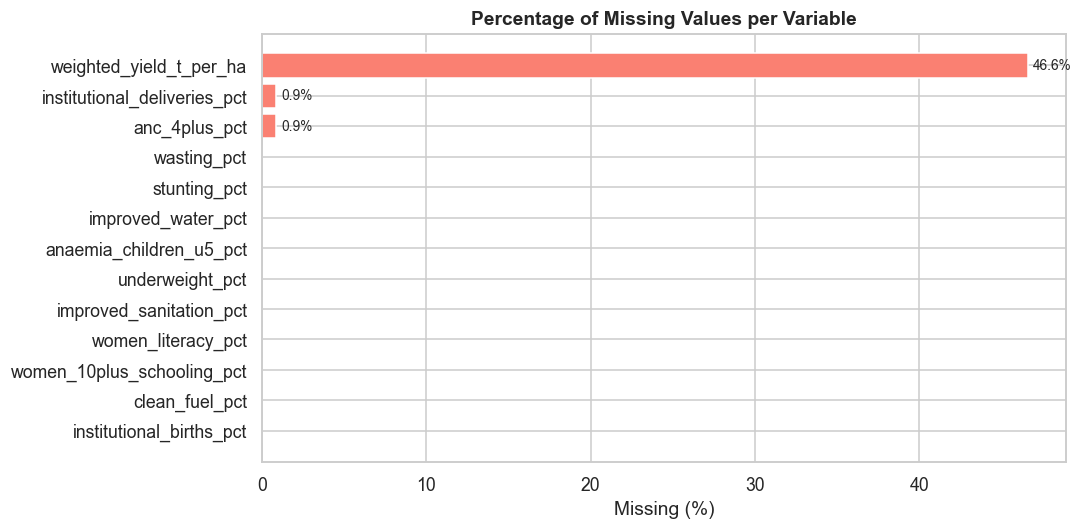

In [4]:
# ---- Missingness Heatmap: understand what we are losing ----
missing_pct = df[all_vars].isnull().mean().sort_values(ascending=False) * 100

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(missing_pct.index, missing_pct.values, color='salmon', edgecolor='white')
ax.set_xlabel('Missing (%)')
ax.set_title('Percentage of Missing Values per Variable', fontweight='bold')
ax.invert_yaxis()
for bar, val in zip(bars, missing_pct.values):
    if val > 0:
        ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2, 
                f'{val:.1f}%', va='center', fontsize=9)
plt.tight_layout()
plt.show()


### Interpretation – Data Quality

The missingness chart above reveals which variables contribute most to row-level data loss. Variables with high missingness rates may reflect districts where certain surveys were not conducted or where the metric is not applicable (e.g., agricultural yield in highly urbanised districts). The listwise deletion approach we use is conservative — it ensures every analysis uses the same set of districts — but it does mean our findings apply to the subset of districts with complete data.

---

## 2. Summary Statistics and Distributions

Before modelling, we need to understand the *shape* of our data. Key questions at this stage:
- Are the nutrition outcome distributions roughly normal, or are they heavily skewed?
- Are there extreme outliers that could distort clustering or regression?
- How much variation exists across districts — are outcomes relatively uniform, or are there large disparities?

We use a combination of descriptive statistics, histograms with kernel density estimates (KDE), and box plots to answer these questions.


In [5]:
# ---- Comprehensive Descriptive Statistics ----
desc = analysis_df[all_vars].describe().T
desc['skewness'] = analysis_df[all_vars].skew()
desc['kurtosis'] = analysis_df[all_vars].kurtosis()
desc['IQR'] = desc['75%'] - desc['25%']
desc['CV (%)'] = (desc['std'] / desc['mean'] * 100).round(1)  # coefficient of variation

# Display with nice formatting
desc[['mean', 'std', 'min', '25%', '50%', '75%', 'max', 'skewness', 'kurtosis', 'IQR', 'CV (%)']].round(2)


,mean,std,min,25%,50%,75%,max,skewness,kurtosis,IQR,CV (%)
stunting_pct,32.06,8.37,14.30,26.02,31.10,37.30,60.60,0.50,0.12,11.27,26.1
wasting_pct,18.29,6.56,4.50,13.62,17.65,21.80,48.00,0.70,0.85,8.18,35.9
underweight_pct,28.20,9.87,7.20,21.12,26.70,34.70,62.40,0.43,-0.15,13.57,35.0
anaemia_children_u5_pct,64.04,13.23,24.90,57.20,66.65,73.10,93.20,-0.65,0.16,15.90,20.7
improved_water_pct,93.74,8.59,41.20,92.50,96.60,99.00,100.00,-3.00,11.41,6.50,9.2
improved_sanitation_pct,75.29,13.53,29.20,67.22,77.70,85.22,99.90,-0.68,0.24,18.00,18.0
clean_fuel_pct,58.87,24.65,8.60,36.22,60.10,81.28,99.00,-0.11,-1.26,45.05,41.9
women_10plus_schooling_pct,42.37,15.28,13.60,30.30,40.90,52.50,88.20,0.56,-0.08,22.20,36.1
women_literacy_pct,75.60,11.91,41.40,67.82,76.25,84.10,99.70,-0.26,-0.40,16.27,15.7
institutional_births_pct,89.80,13.31,21.40,86.70,94.85,98.30,100.00,-2.35,6.34,11.60,14.8


### Reading the Summary Table

- **Coefficient of Variation (CV):** Measures relative variability. A CV above ~30% indicates substantial cross-district inequality in that metric.
- **Skewness:** Values near 0 indicate symmetry. Positive skew means a right tail (a few districts with very high values); negative skew means a left tail.
- **Kurtosis:** High kurtosis (>3) indicates heavy tails — more extreme values than a normal distribution would predict.


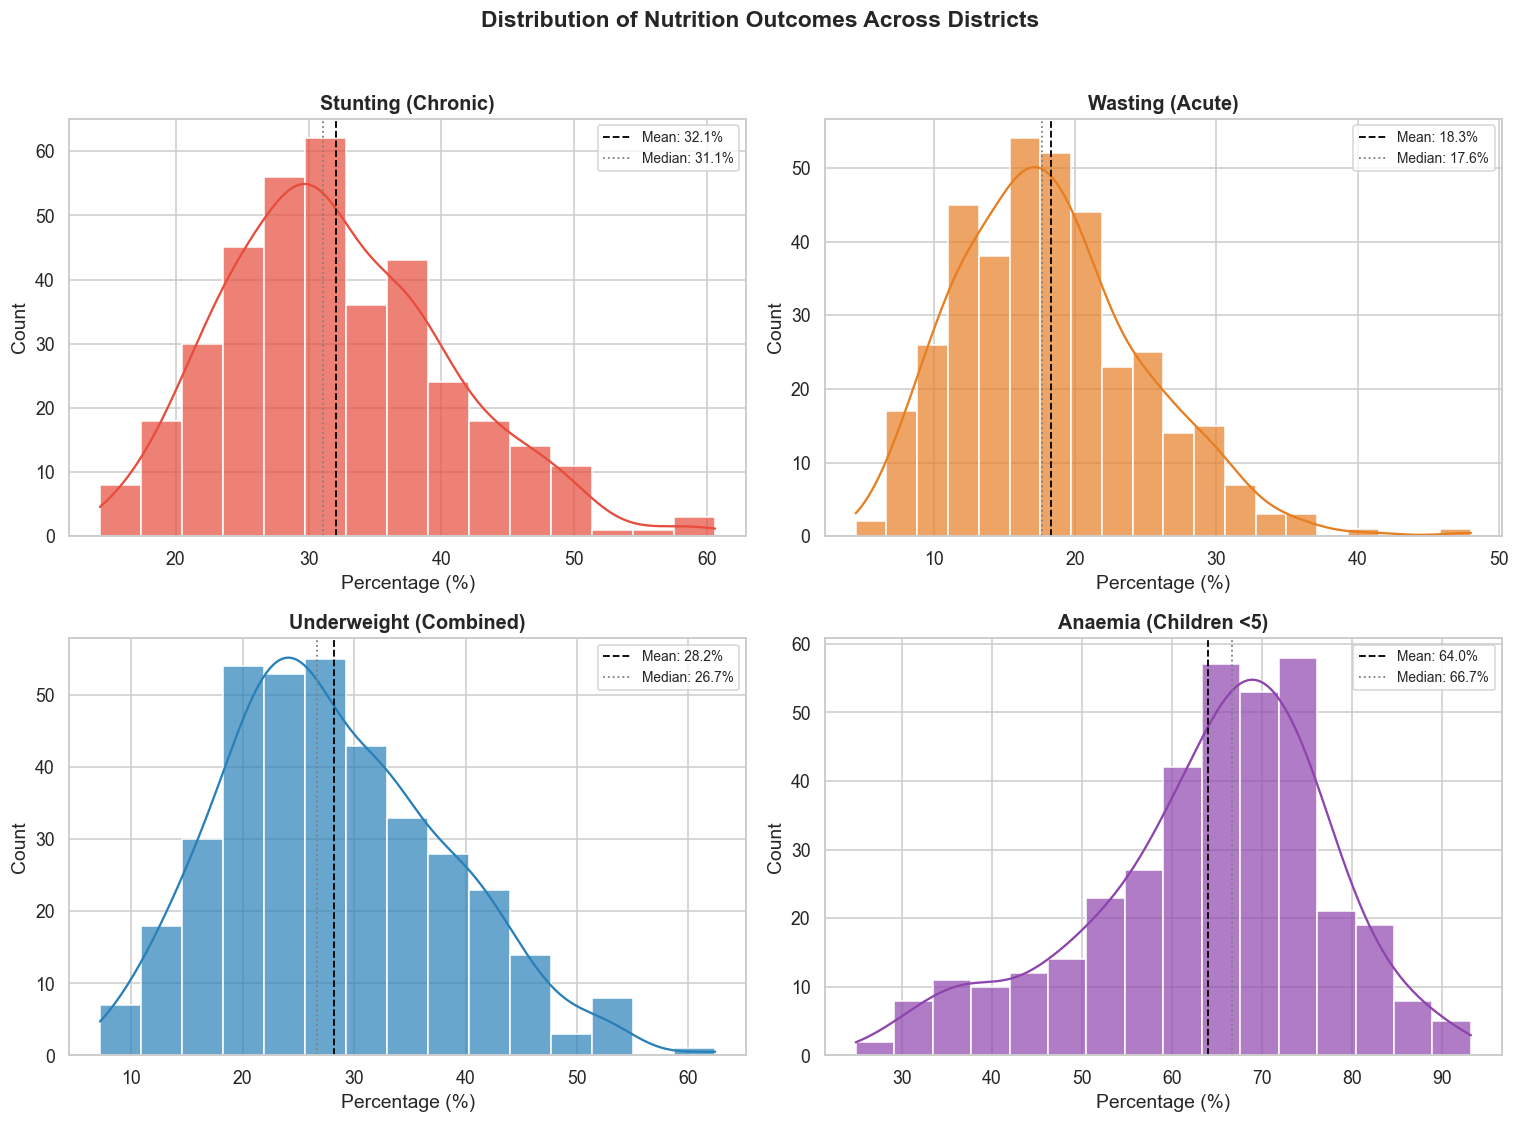

In [6]:
# ---- Distribution Plots: Nutrition Outcomes ----
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
colors = ['#e74c3c', '#e67e22', '#2980b9', '#8e44ad']
titles = ['Stunting (Chronic)', 'Wasting (Acute)', 'Underweight (Combined)', 'Anaemia (Children <5)']

for i, (col, color, title) in enumerate(zip(nutrition_outcomes, colors, titles)):
    ax = axes[i // 2][i % 2]
    sns.histplot(analysis_df[col], kde=True, ax=ax, color=color, edgecolor='white', alpha=0.7)
    
    # Add mean and median reference lines
    mean_val = analysis_df[col].mean()
    median_val = analysis_df[col].median()
    ax.axvline(mean_val, color='black', linestyle='--', linewidth=1.2, label=f'Mean: {mean_val:.1f}%')
    ax.axvline(median_val, color='grey', linestyle=':', linewidth=1.2, label=f'Median: {median_val:.1f}%')
    
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel('Percentage (%)')
    ax.legend(fontsize=9)

plt.suptitle('Distribution of Nutrition Outcomes Across Districts', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


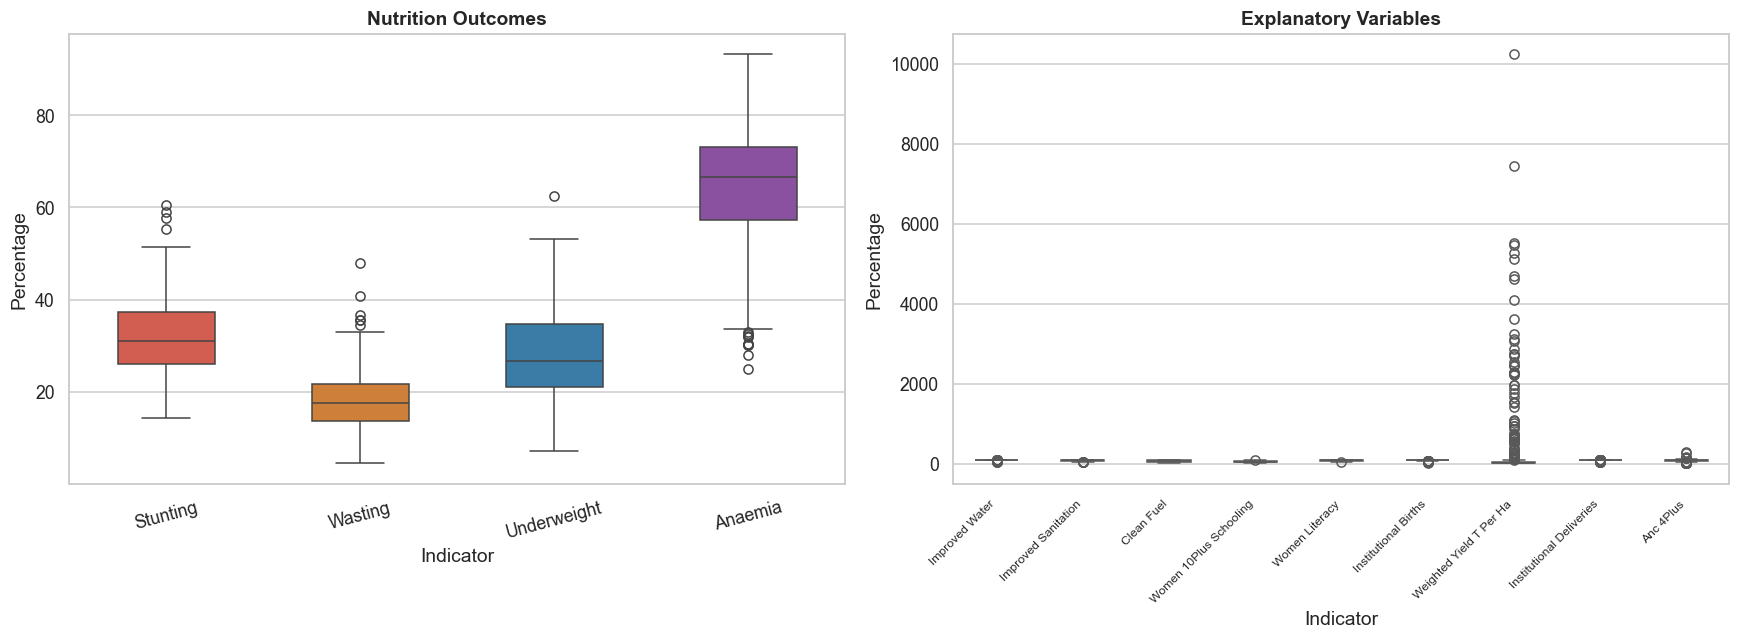

In [7]:
# ---- Box Plots: Compare spread and outliers side-by-side ----
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Nutrition outcomes
melted_nut = analysis_df[nutrition_outcomes].melt(var_name='Indicator', value_name='Percentage')
sns.boxplot(data=melted_nut, x='Indicator', y='Percentage', palette=colors, ax=axes[0], width=0.5)
axes[0].set_title('Nutrition Outcomes', fontweight='bold')
axes[0].set_xticklabels(['Stunting', 'Wasting', 'Underweight', 'Anaemia'], rotation=15)

# Explanatory variables
melted_exp = analysis_df[explanatory_vars].melt(var_name='Indicator', value_name='Percentage')
sns.boxplot(data=melted_exp, x='Indicator', y='Percentage', palette='Set2', ax=axes[1], width=0.5)
axes[1].set_title('Explanatory Variables', fontweight='bold')
axes[1].set_xticklabels([v.replace('_pct','').replace('_',' ').title() for v in explanatory_vars], rotation=45, ha='right', fontsize=8)

plt.tight_layout()
plt.show()


In [8]:
# ---- Outlier Detection using IQR Method ----
outlier_counts = {}
for col in nutrition_outcomes:
    Q1, Q3 = analysis_df[col].quantile([0.25, 0.75])
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    n_outliers = ((analysis_df[col] < lower) | (analysis_df[col] > upper)).sum()
    outlier_counts[col] = n_outliers

outlier_df = pd.DataFrame.from_dict(outlier_counts, orient='index', columns=['Outlier Count'])
outlier_df['% of Districts'] = (outlier_df['Outlier Count'] / len(analysis_df) * 100).round(1)
print("Outlier Detection (IQR Method):")
outlier_df


Outlier Detection (IQR Method):


,Outlier Count,% of Districts
stunting_pct,4,1.1
wasting_pct,6,1.6
underweight_pct,1,0.3
anaemia_children_u5_pct,10,2.7


### Interpretation – Distributions

Several patterns emerge:

1. **Stunting** tends to be the most prevalent form of malnutrition, with a wide distribution reflecting enormous district-level inequality. The gap between mean and median, combined with the skewness value, tells us whether the distribution is pulled by a long tail of particularly affected districts.

2. **Wasting** typically shows a tighter distribution — acute malnutrition is more evenly spread and may be less responsive to the structural determinants we are measuring (it is often driven by acute shocks like disease outbreaks or food crises).

3. **Anaemia** in children under 5 is often the most uniformly high indicator, suggesting it is a near-universal challenge rather than one concentrated in the most disadvantaged districts.

4. Among explanatory variables, **clean fuel access** and **women's schooling** tend to show the widest spread, suggesting these are areas where district-level inequality is most pronounced — and therefore where targeted interventions could be most impactful.

---

## 3. Bivariate and Multivariate Correlation Analysis

Correlation analysis helps us understand which explanatory variables move *together* with nutrition outcomes. We use Pearson correlations (linear relationships) and supplement with Spearman rank correlations (monotonic but possibly non-linear relationships) to avoid missing important patterns.

**Important caveat:** Correlation does not establish causation. Two variables may be correlated because they share a common underlying cause (e.g., poverty drives both low sanitation and high stunting).


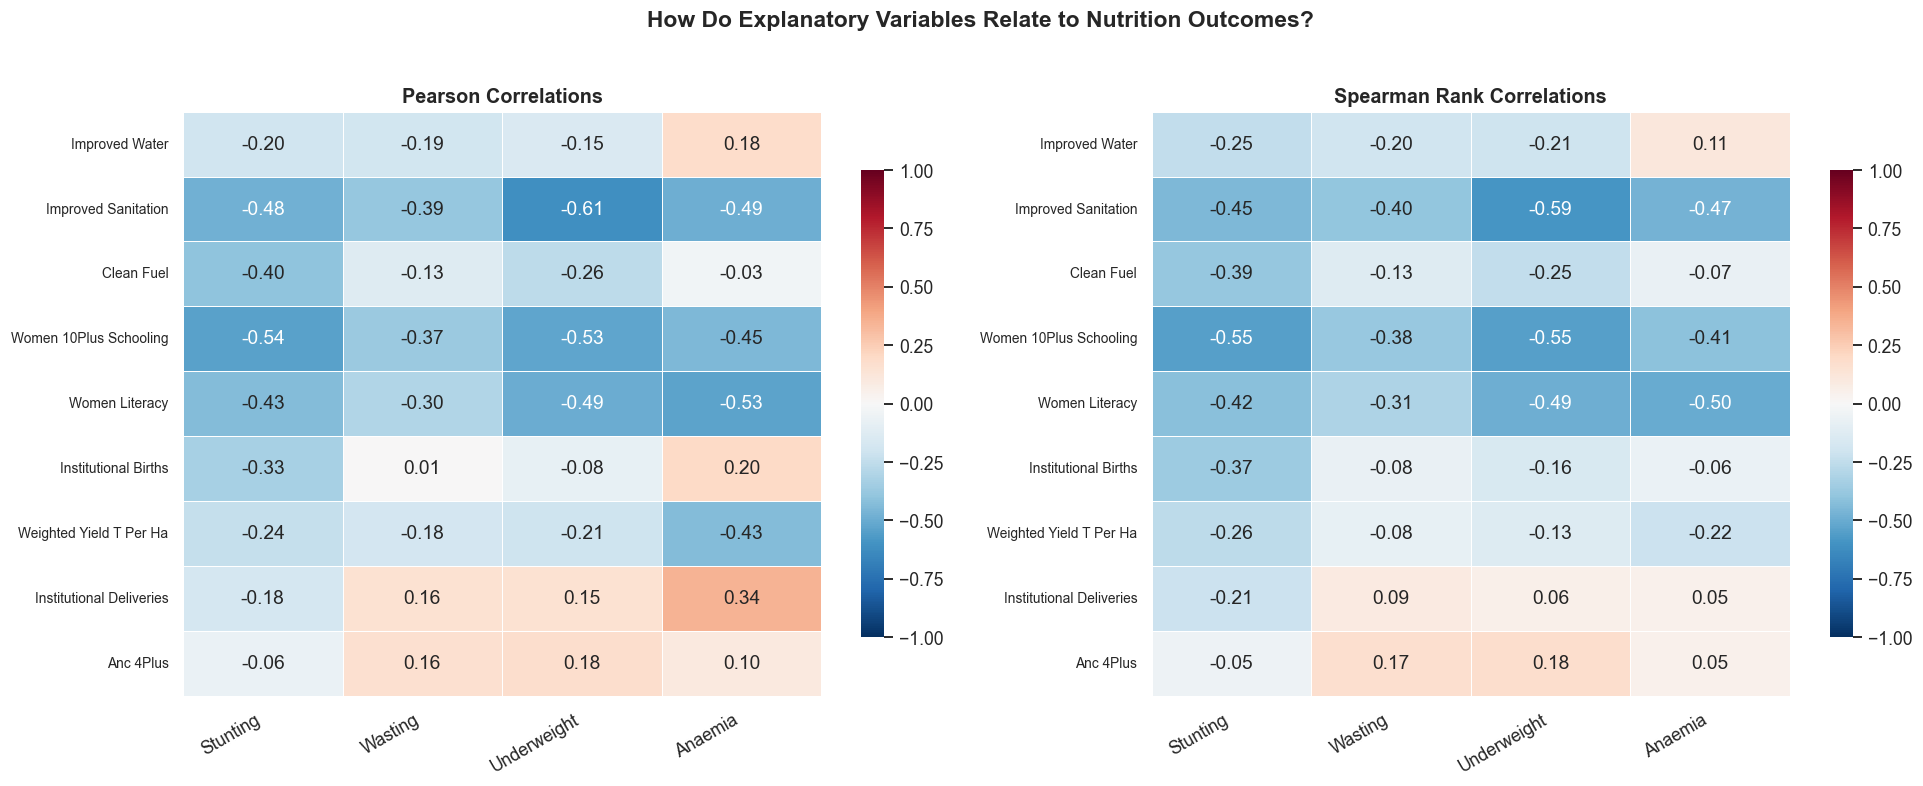

In [9]:
# ---- Full Correlation Matrix (Nutrition Outcomes + Explanatory) ----
corr_pearson = analysis_df[all_vars].corr(method='pearson')
corr_spearman = analysis_df[all_vars].corr(method='spearman')

# Extract cross-correlations (explanatory → outcomes)
cross_corr = corr_pearson.loc[explanatory_vars, nutrition_outcomes]

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Pearson
sns.heatmap(cross_corr, annot=True, cmap='RdBu_r', fmt='.2f', vmin=-1, vmax=1,
            linewidths=0.5, ax=axes[0], cbar_kws={'shrink': 0.8})
axes[0].set_title('Pearson Correlations', fontweight='bold', fontsize=13)
axes[0].set_yticklabels([v.replace('_pct','').replace('_',' ').title() for v in explanatory_vars], fontsize=9)
axes[0].set_xticklabels(['Stunting', 'Wasting', 'Underweight', 'Anaemia'], rotation=30, ha='right')

# Spearman
cross_spearman = corr_spearman.loc[explanatory_vars, nutrition_outcomes]
sns.heatmap(cross_spearman, annot=True, cmap='RdBu_r', fmt='.2f', vmin=-1, vmax=1,
            linewidths=0.5, ax=axes[1], cbar_kws={'shrink': 0.8})
axes[1].set_title('Spearman Rank Correlations', fontweight='bold', fontsize=13)
axes[1].set_yticklabels([v.replace('_pct','').replace('_',' ').title() for v in explanatory_vars], fontsize=9)
axes[1].set_xticklabels(['Stunting', 'Wasting', 'Underweight', 'Anaemia'], rotation=30, ha='right')

plt.suptitle('How Do Explanatory Variables Relate to Nutrition Outcomes?', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


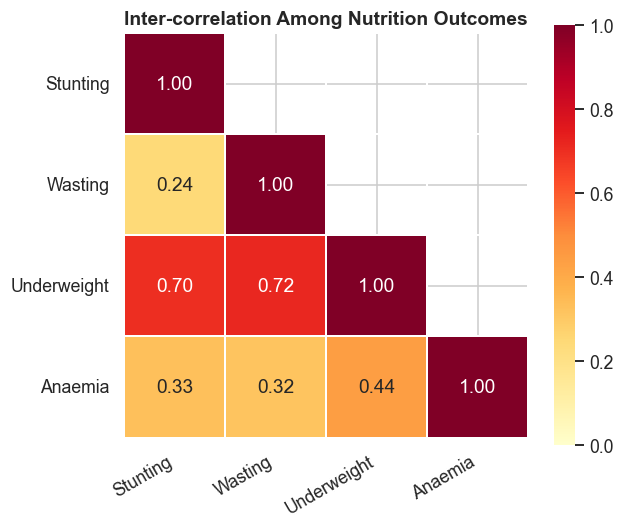

In [10]:
# ---- Correlation Between Nutrition Outcomes Themselves ----
outcome_corr = analysis_df[nutrition_outcomes].corr()

fig, ax = plt.subplots(figsize=(6, 5))
mask = np.triu(np.ones_like(outcome_corr, dtype=bool), k=1)
sns.heatmap(outcome_corr, annot=True, cmap='YlOrRd', fmt='.2f', mask=mask,
            square=True, linewidths=1, ax=ax, vmin=0, vmax=1)
ax.set_title('Inter-correlation Among Nutrition Outcomes', fontweight='bold')
ax.set_xticklabels(['Stunting', 'Wasting', 'Underweight', 'Anaemia'], rotation=30, ha='right')
ax.set_yticklabels(['Stunting', 'Wasting', 'Underweight', 'Anaemia'])
plt.tight_layout()
plt.show()


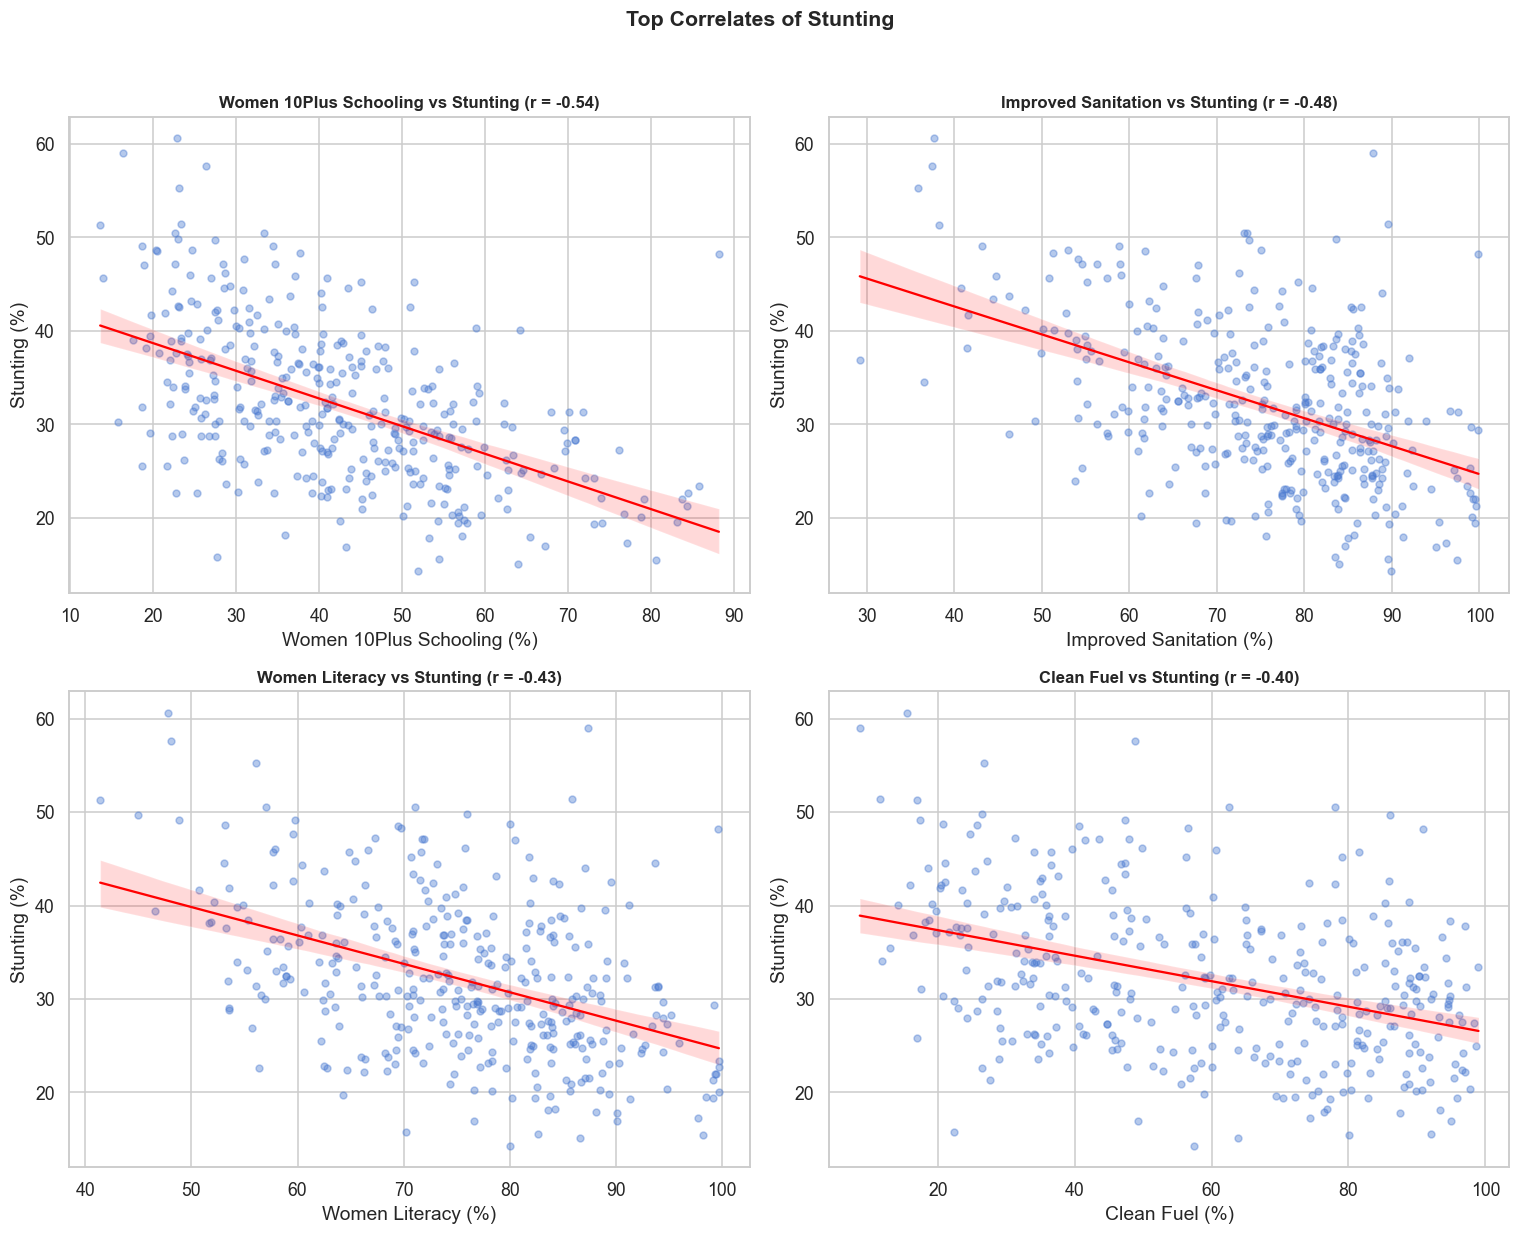

In [11]:
# ---- Key Scatter Plots with Regression Lines ----
# Select the top 4 strongest correlates of stunting
stunting_corr = cross_corr['stunting_pct'].abs().sort_values(ascending=False)
top_predictors = stunting_corr.head(4).index.tolist()

fig, axes = plt.subplots(2, 2, figsize=(14, 11))
for i, var in enumerate(top_predictors):
    ax = axes[i // 2][i % 2]
    r_val = cross_corr.loc[var, 'stunting_pct']
    sns.regplot(data=analysis_df, x=var, y='stunting_pct', ax=ax,
                scatter_kws={'alpha': 0.4, 's': 20}, line_kws={'color': 'red', 'linewidth': 1.5})
    nice_name = var.replace('_pct', '').replace('_', ' ').title()
    ax.set_title(f'{nice_name} vs Stunting (r = {r_val:.2f})', fontweight='bold', fontsize=11)
    ax.set_xlabel(f'{nice_name} (%)')
    ax.set_ylabel('Stunting (%)')

plt.suptitle('Top Correlates of Stunting', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


### Interpretation – Correlations

**Key findings from the heatmaps:**

1. **Women's education and literacy** are consistently among the strongest negative correlates of stunting and underweight. Districts where women have more schooling tend to have significantly lower rates of chronic malnutrition. This aligns with extensive public health literature: educated mothers are better able to navigate healthcare systems, adopt improved feeding practices, and recognise early signs of malnutrition.

2. **Sanitation and clean fuel access** also show strong negative correlations with malnutrition. Poor sanitation leads to repeated enteric infections, which impair nutrient absorption — a pathway known as environmental enteropathy.

3. **Wasting** tends to show weaker correlations with structural variables. This is expected: wasting is an acute condition often triggered by short-term shocks (illness, food insecurity episodes) rather than the chronic deprivation that structural indicators capture.

4. The **inter-correlation among outcomes** reveals that stunting and underweight are highly correlated (both reflect chronic processes), while wasting is somewhat independent. Anaemia sits in between — it has a moderate association with all other outcomes.

5. Comparing Pearson and Spearman correlations: if the Spearman value is substantially higher, the relationship may be monotonic but non-linear (e.g., improvements in sanitation from 20% → 40% may matter more than from 70% → 90%). This has implications for diminishing returns in policy.

---

## 4. Multicollinearity Diagnostics (Variance Inflation Factor)

Before using multiple explanatory variables together in predictive models, we need to check whether they are too highly correlated with *each other*. If two variables (e.g., `women_literacy_pct` and `women_10plus_schooling_pct`) carry essentially the same information, including both inflates standard errors and makes it impossible to isolate individual effects.

The **Variance Inflation Factor (VIF)** quantifies this: a VIF above 5 suggests moderate multicollinearity, and above 10 signals a serious problem.


In [12]:
# ---- VIF Calculation ----
X_expl = analysis_df[explanatory_vars].copy()
X_expl_scaled = StandardScaler().fit_transform(X_expl)
X_expl_scaled_df = pd.DataFrame(X_expl_scaled, columns=explanatory_vars)

vif_data = pd.DataFrame({
    'Variable': explanatory_vars,
    'VIF': [variance_inflation_factor(X_expl_scaled_df.values, i) for i in range(len(explanatory_vars))]
}).sort_values('VIF', ascending=False).reset_index(drop=True)

vif_data['Flag'] = vif_data['VIF'].apply(lambda x: '⚠️ HIGH' if x > 10 else ('⚡ Moderate' if x > 5 else '✅ OK'))
print("Variance Inflation Factors:")
vif_data


Variance Inflation Factors:


,Variable,VIF,Flag
0,women_10plus_schooling_pct,3.382660,✅ OK
1,women_literacy_pct,3.012717,✅ OK
2,institutional_births_pct,2.672297,✅ OK
3,institutional_deliveries_pct,2.659253,✅ OK
4,clean_fuel_pct,2.399191,✅ OK
5,improved_sanitation_pct,2.326745,✅ OK
6,improved_water_pct,1.546927,✅ OK
7,anc_4plus_pct,1.452586,✅ OK
8,weighted_yield_t_per_ha,1.332429,✅ OK


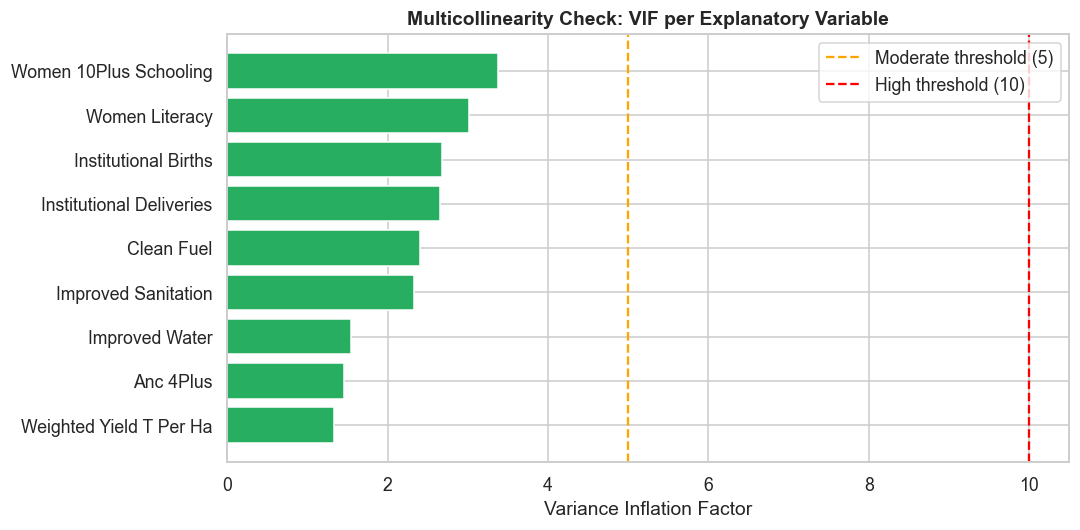

In [13]:
# ---- VIF Bar Chart ----
fig, ax = plt.subplots(figsize=(10, 5))
bar_colors = ['#e74c3c' if v > 10 else '#f39c12' if v > 5 else '#27ae60' for v in vif_data['VIF']]
ax.barh(vif_data['Variable'].apply(lambda x: x.replace('_pct','').replace('_',' ').title()),
        vif_data['VIF'], color=bar_colors, edgecolor='white')
ax.axvline(5, color='orange', linestyle='--', label='Moderate threshold (5)')
ax.axvline(10, color='red', linestyle='--', label='High threshold (10)')
ax.set_xlabel('Variance Inflation Factor')
ax.set_title('Multicollinearity Check: VIF per Explanatory Variable', fontweight='bold')
ax.legend()
ax.invert_yaxis()
plt.tight_layout()
plt.show()


### Interpretation – VIF Analysis

Variables with high VIF values are strongly predicted by the other explanatory variables. For instance, `women_literacy_pct` and `women_10plus_schooling_pct` both capture female education and may be near-duplicates. Similarly, `institutional_births_pct` and `institutional_deliveries_pct` likely measure the same underlying construct.

**Action for modelling:** In the predictive model (Section 10), Random Forests are relatively robust to multicollinearity for *prediction*, but feature importance rankings can be misleading when two correlated features split importance between them. We will keep this in mind during interpretation.

---

## 5. State-Level Geographic Analysis

Malnutrition in India has a strong geographic pattern — northern and central states (the so-called "BIMARU" belt: Bihar, Madhya Pradesh, Rajasthan, Uttar Pradesh) historically show worse outcomes. We aggregate to the state level and visualise the top and bottom performers.


In [14]:
# ---- State-Level Aggregation ----
state_df = analysis_df.groupby('state_name').agg(
    n_districts=('stunting_pct', 'count'),
    **{col: (col, 'mean') for col in nutrition_outcomes + explanatory_vars}
).reset_index()

# Create a composite vulnerability index (average of z-scored nutrition outcomes)
for col in nutrition_outcomes:
    state_df[f'{col}_z'] = (state_df[col] - state_df[col].mean()) / state_df[col].std()

state_df['vulnerability_index'] = state_df[[f'{c}_z' for c in nutrition_outcomes]].mean(axis=1)
state_df = state_df.sort_values('vulnerability_index', ascending=False)

print(f"Number of states/UTs: {state_df.shape[0]}")
state_df[['state_name', 'n_districts', 'stunting_pct', 'wasting_pct', 
           'underweight_pct', 'anaemia_children_u5_pct', 'vulnerability_index']].head(10)


Number of states/UTs: 23

,state_name,n_districts,stunting_pct,wasting_pct,underweight_pct,anaemia_children_u5_pct,vulnerability_index
6,Gujarat,33,38.660606,26.139394,40.330303,79.836364,1.738228
8,Jharkhand,24,40.187500,23.108333,40.400000,68.216667,1.404969
19,The Dadra And Nagar Haveli And Daman And Diu,3,35.433333,21.166667,33.300000,73.366667,0.945019
18,Telangana,31,33.245161,22.596774,33.341935,70.338710,0.859815
3,Assam,27,34.881481,20.885185,31.766667,69.485185,0.770964
22,West Bengal,19,33.368421,20.921053,32.689474,69.652632,0.738253
9,Karnataka,30,34.580000,19.230000,31.296667,64.553333,0.548704
15,Rajasthan,33,31.742424,18.045455,28.400000,72.200000,0.414013
20,Tripura,8,32.962500,18.912500,26.162500,65.850000,0.308172
1,Andhra Pradesh,13,30.384615,16.084615,28.769231,63.476923,0.076272


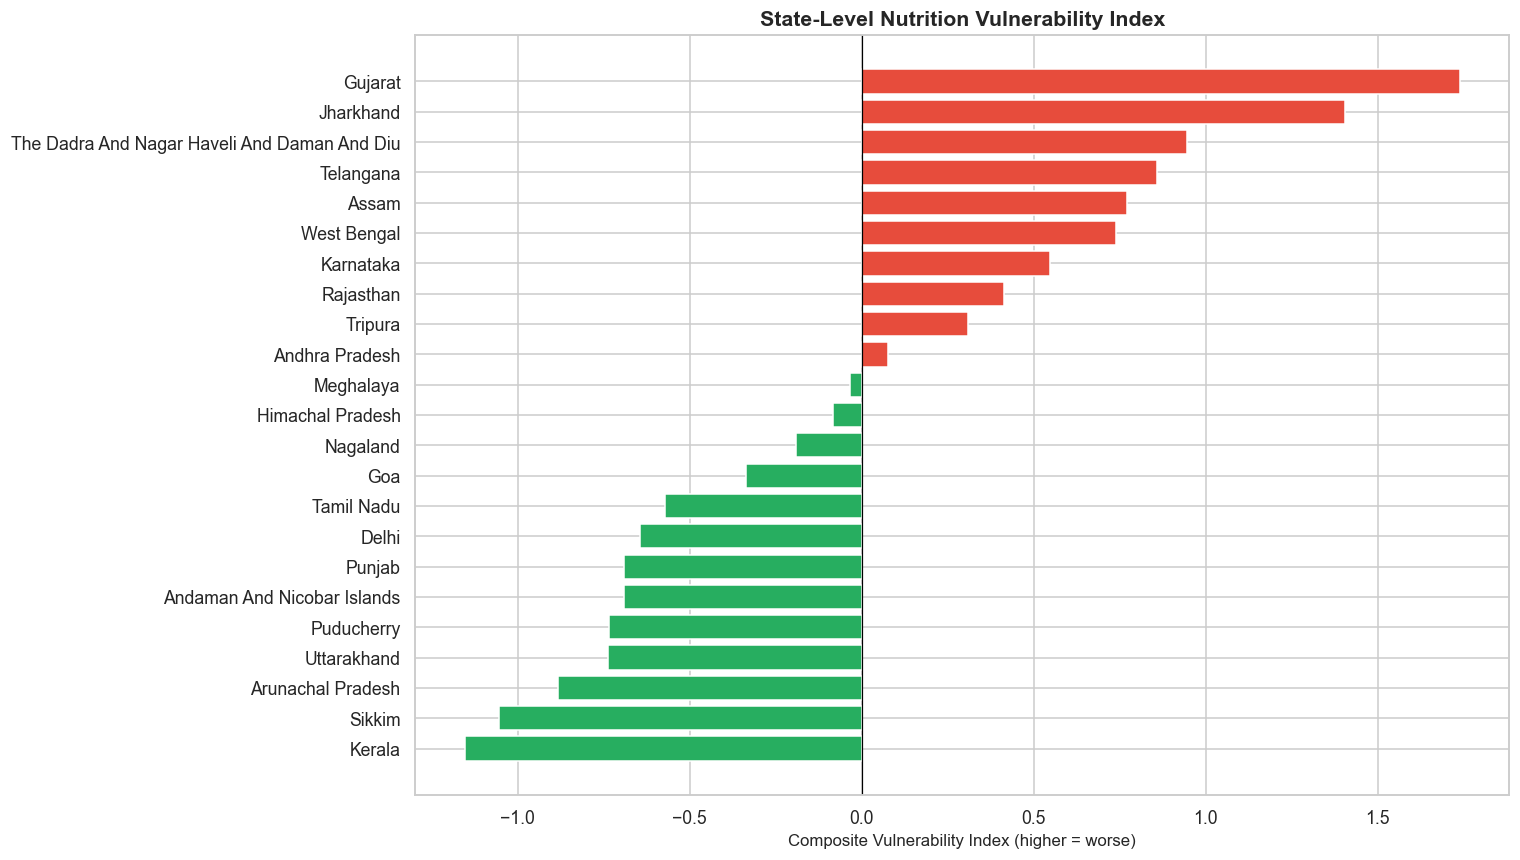

In [15]:
# ---- Composite Vulnerability Index by State ----
fig, ax = plt.subplots(figsize=(14, 8))
colors_bar = ['#e74c3c' if v > 0 else '#27ae60' for v in state_df['vulnerability_index']]
ax.barh(state_df['state_name'], state_df['vulnerability_index'], color=colors_bar, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Composite Vulnerability Index (higher = worse)', fontsize=11)
ax.set_title('State-Level Nutrition Vulnerability Index', fontweight='bold', fontsize=14)
ax.invert_yaxis()
plt.tight_layout()
plt.show()


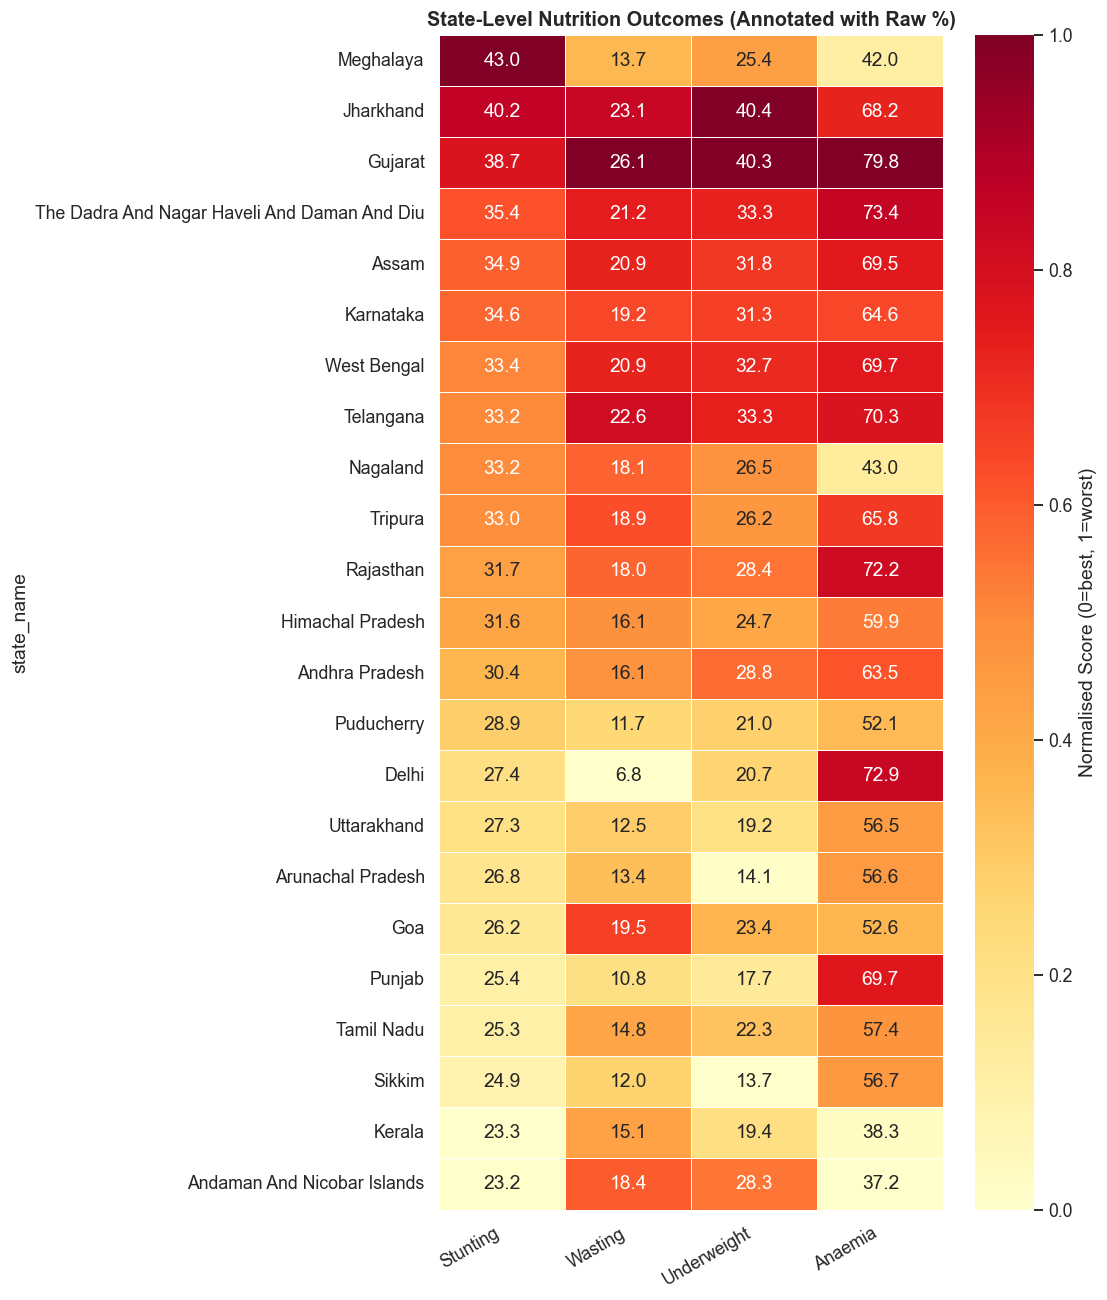

In [16]:
# ---- State-Level Heatmap of All Indicators ----
state_heatmap = state_df.set_index('state_name')[nutrition_outcomes].copy()
# Normalise each column to 0-1 for comparable colour scales
state_heatmap_norm = (state_heatmap - state_heatmap.min()) / (state_heatmap.max() - state_heatmap.min())

fig, ax = plt.subplots(figsize=(10, 12))
sns.heatmap(state_heatmap_norm.sort_values('stunting_pct', ascending=False),
            cmap='YlOrRd', annot=state_heatmap.sort_values('stunting_pct', ascending=False),
            fmt='.1f', linewidths=0.5, ax=ax, cbar_kws={'label': 'Normalised Score (0=best, 1=worst)'})
ax.set_title('State-Level Nutrition Outcomes (Annotated with Raw %)', fontweight='bold', fontsize=13)
ax.set_xticklabels(['Stunting', 'Wasting', 'Underweight', 'Anaemia'], rotation=30, ha='right')
plt.tight_layout()
plt.show()


### Interpretation – Geographic Patterns

The vulnerability index confirms a well-documented north-south gradient in Indian nutrition:
- States at the top of the chart (highest vulnerability) tend to be in north/central India, with histories of lower investment in education and health infrastructure.
- Southern and northeastern states generally perform better, though significant within-state variation exists (which is why district-level analysis matters).
- The heatmap reveals that states don't always rank the same across all indicators — a state may fare relatively well on wasting but poorly on anaemia, suggesting different causal pathways.

---

## 6. Principal Component Analysis (PCA)

Our explanatory variables are numerous and correlated. PCA transforms them into a smaller set of uncorrelated **principal components** that capture the most variance in the data. This serves two purposes:
1. **Visualisation:** We can project the high-dimensional data onto 2D for plotting.
2. **Dimensionality reduction:** We can understand how many independent dimensions of variation actually exist in the data.

We apply PCA to the combined set of nutrition outcomes + explanatory variables to reveal the latent structure of district-level wellbeing.


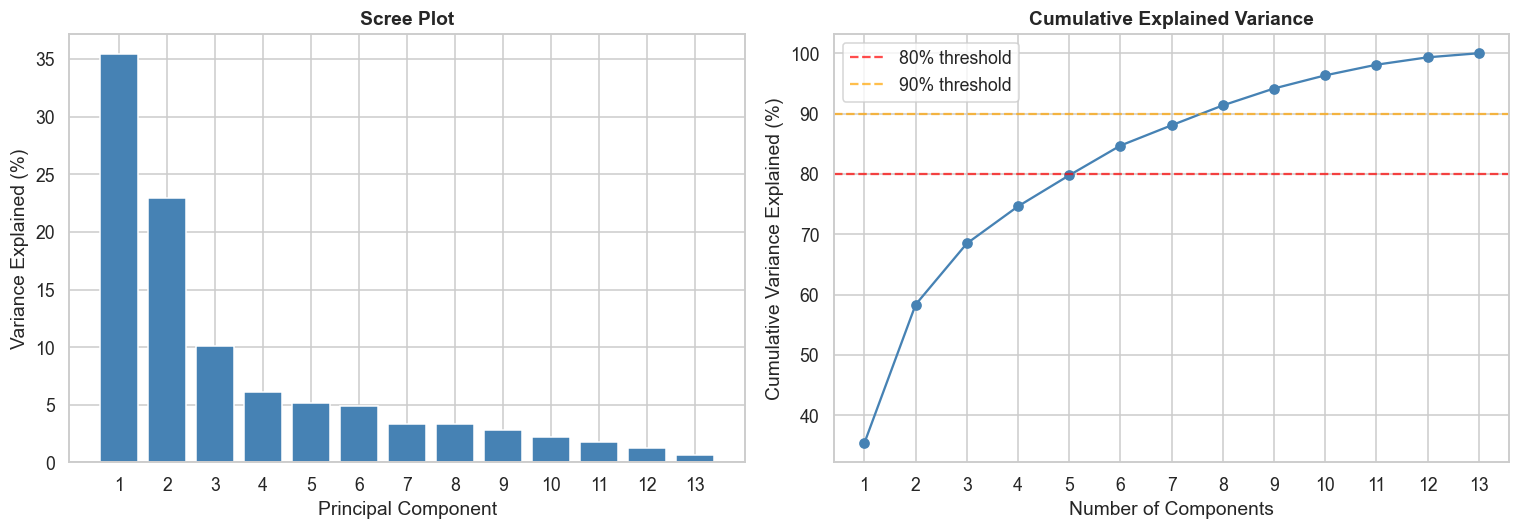

Components needed for 80% variance: 6
Components needed for 90% variance: 8


In [17]:
# ---- PCA on All Variables ----
scaler = StandardScaler()
X_all_scaled = scaler.fit_transform(analysis_df[all_vars])

pca_full = PCA()
X_pca_full = pca_full.fit_transform(X_all_scaled)

# Explained variance
explained_var = pca_full.explained_variance_ratio_
cumulative_var = np.cumsum(explained_var)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scree plot
axes[0].bar(range(1, len(explained_var)+1), explained_var * 100, color='steelblue', edgecolor='white')
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Variance Explained (%)')
axes[0].set_title('Scree Plot', fontweight='bold')
axes[0].set_xticks(range(1, len(explained_var)+1))

# Cumulative variance
axes[1].plot(range(1, len(cumulative_var)+1), cumulative_var * 100, marker='o', color='steelblue')
axes[1].axhline(80, color='red', linestyle='--', alpha=0.7, label='80% threshold')
axes[1].axhline(90, color='orange', linestyle='--', alpha=0.7, label='90% threshold')
axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Cumulative Variance Explained (%)')
axes[1].set_title('Cumulative Explained Variance', fontweight='bold')
axes[1].legend()
axes[1].set_xticks(range(1, len(cumulative_var)+1))

plt.tight_layout()
plt.show()

n_80 = np.argmax(cumulative_var >= 0.80) + 1
n_90 = np.argmax(cumulative_var >= 0.90) + 1
print(f"Components needed for 80% variance: {n_80}")
print(f"Components needed for 90% variance: {n_90}")


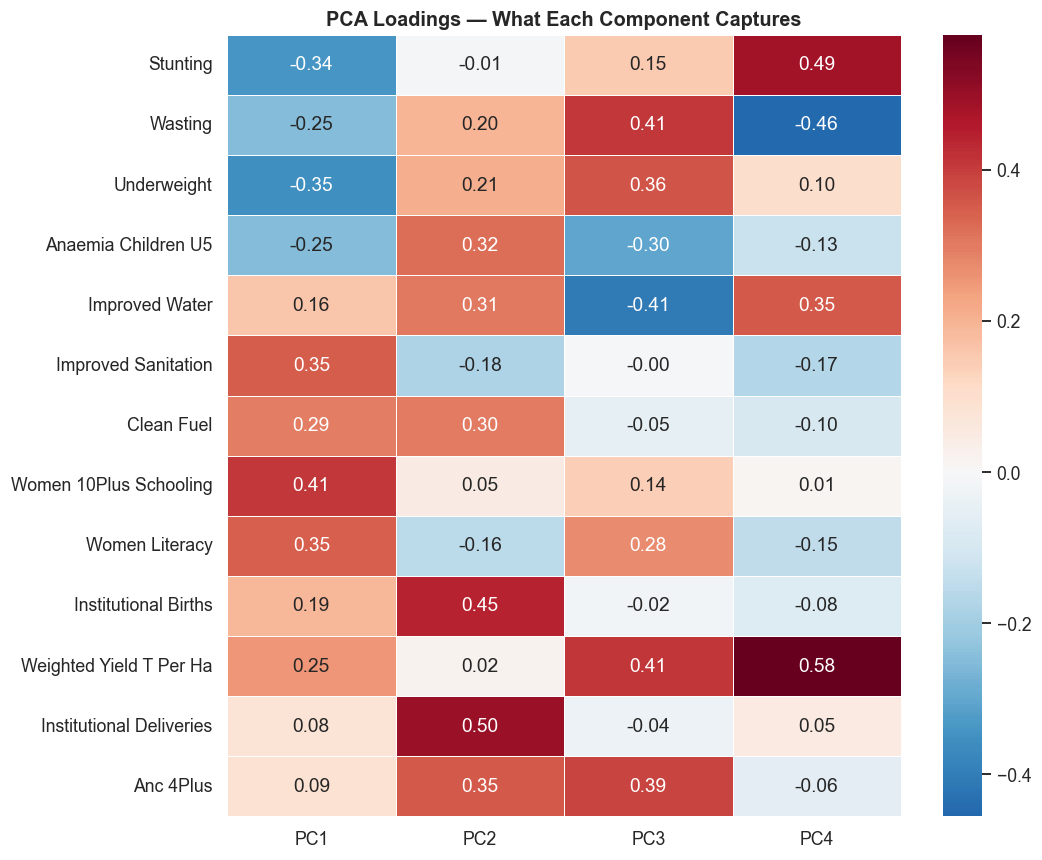

In [18]:
# ---- PCA Loadings: What does each component represent? ----
loadings = pd.DataFrame(
    pca_full.components_[:4].T,  # First 4 components
    columns=[f'PC{i+1}' for i in range(4)],
    index=[v.replace('_pct','').replace('_',' ').title() for v in all_vars]
)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(loadings, annot=True, cmap='RdBu_r', fmt='.2f', center=0, linewidths=0.5, ax=ax)
ax.set_title('PCA Loadings — What Each Component Captures', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()


### Interpretation – PCA

The PCA loadings reveal the latent dimensions of district wellbeing:

- **PC1** (the largest component) typically captures **overall development** — it loads heavily on education, sanitation, clean fuel, *and* inversely on malnutrition outcomes. Districts scoring high on PC1 are well-developed across the board. This confirms that malnutrition is deeply embedded in broader structural deprivation.

- **PC2** often separates indicators that don't co-vary perfectly — for instance, agricultural yield may load independently from healthcare access, capturing a rural vs. urban dimension.

- The scree plot tells us how many meaningful dimensions exist. If 2–3 components explain 70–80% of variance, that means the 13 variables are largely redundant and district wellbeing can be characterised along just a few axes.

---

---
## 6b. Composite Malnutrition Index and OLS Regression

The PCA above used all variables together. Here we run a focused analysis:
- **PCA on the four nutrition outcomes only** to produce a single composite malnutrition index (PC1).
- **OLS regression** with four cross-sector predictors to isolate each pathway's independent association.

Z-scored columns (`z_*`) already available in the loaded DataFrame are used throughout.


## 1. PCA-based composite malnutrition index

PCA is applied to the four normalized child malnutrition indicators:

- `z_stunting_pct`
- `z_wasting_pct`
- `z_underweight_pct`
- `z_anaemia_children_u5_pct`

The first principal component is used as the composite malnutrition index. Its sign is flipped if necessary so that higher values always represent worse malnutrition burden.


In [19]:
pca_columns = [
    'z_stunting_pct',
    'z_wasting_pct',
    'z_underweight_pct',
    'z_anaemia_children_u5_pct',
]

pca_df = analysis[['district_id', 'state_name', 'district_name'] + pca_columns].dropna().copy()
pca_model = PCA(n_components=1)
pc1_scores = pca_model.fit_transform(pca_df[pca_columns].to_numpy(dtype=float)).ravel()
loadings = pd.Series(pca_model.components_[0], index=pca_columns, name='pc1_loading')

# Make the index direction intuitive: higher score = worse malnutrition burden.
if loadings.mean() < 0:
    pc1_scores = -pc1_scores
    loadings = -loadings

pca_df['malnutrition_index_pc1'] = pc1_scores
pca_df['z_malnutrition_index_pc1'] = (
    pca_df['malnutrition_index_pc1'] - pca_df['malnutrition_index_pc1'].mean()
) / pca_df['malnutrition_index_pc1'].std(ddof=0)

pca_loadings = loadings.reset_index()
pca_loadings.columns = ['variable', 'pc1_loading']
pca_loadings['explained_variance_ratio'] = pca_model.explained_variance_ratio_[0]

analysis_pca = analysis.merge(
    pca_df[['district_id', 'malnutrition_index_pc1', 'z_malnutrition_index_pc1']],
    on='district_id',
    how='left',
)

display(pca_loadings)
print('Explained variance ratio (PC1):', round(float(pca_model.explained_variance_ratio_[0]), 4))

pca_loadings.to_csv(PCA_DIR / 'pca_loadings.csv', index=False)
pca_df.to_csv(PCA_DIR / 'district_malnutrition_pca_scores.csv', index=False)


,variable,pc1_loading,explained_variance_ratio
0,z_stunting_pct,0.484820,0.598088
1,z_wasting_pct,0.484187,0.598088
2,z_underweight_pct,0.609769,0.598088
3,z_anaemia_children_u5_pct,0.398365,0.598088


Explained variance ratio (PC1): 0.5981


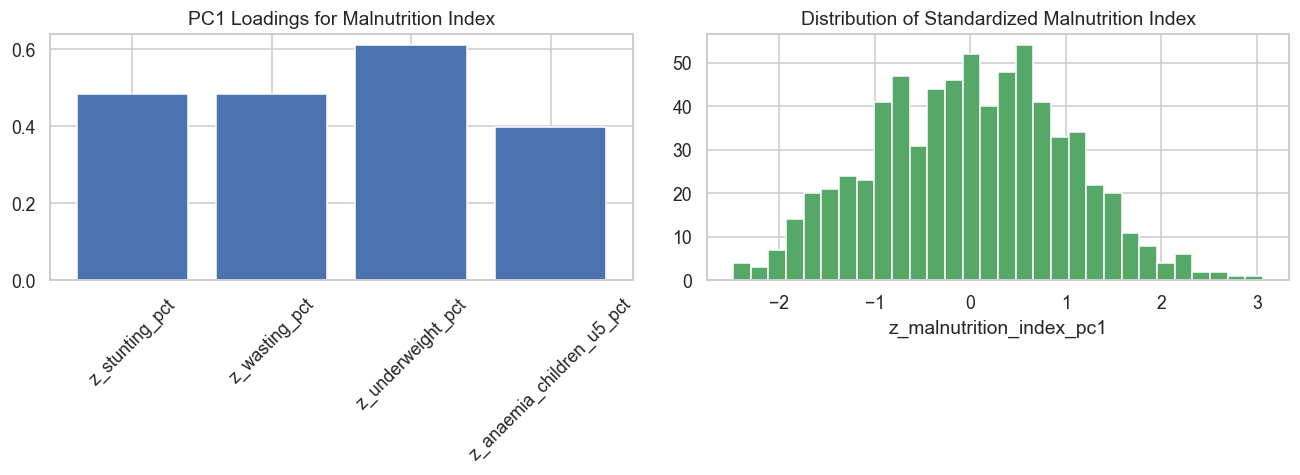

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].bar(pca_loadings['variable'], pca_loadings['pc1_loading'], color='#4C72B0')
axes[0].set_title('PC1 Loadings for Malnutrition Index')
axes[0].tick_params(axis='x', rotation=45)

axes[1].hist(pca_df['z_malnutrition_index_pc1'], bins=30, color='#55A868', edgecolor='white')
axes[1].set_title('Distribution of Standardized Malnutrition Index')
axes[1].set_xlabel('z_malnutrition_index_pc1')

plt.tight_layout()
plt.show()


## 2. Regression setup

The dependent variable is the standardized PCA malnutrition index.

Predictor choice is intentionally small and justified:

- `z_weighted_yield_t_per_ha`: agriculture productivity pathway
- `z_improved_sanitation_pct`: water/sanitation pathway
- `z_institutional_deliveries_pct`: healthcare access pathway
- `z_women_10plus_schooling_pct`: socioeconomic control

Sanitation is used instead of JJM in the main model because it is better covered and more directly usable in the current merged dataset.


In [21]:
def fit_ols(dataframe, y_col, x_cols, model_name):
    model_df = dataframe[[y_col] + x_cols].dropna().copy()
    y = model_df[y_col].to_numpy(dtype=float)
    X_raw = model_df[x_cols].to_numpy(dtype=float)
    X = np.column_stack([np.ones(len(model_df)), X_raw])
    variable_names = ['Intercept'] + x_cols

    beta = np.linalg.lstsq(X, y, rcond=None)[0]
    fitted = X @ beta
    resid = y - fitted
    n_obs, n_params = X.shape
    df_resid = n_obs - n_params

    ss_res = float(resid.T @ resid)
    ss_tot = float(((y - y.mean()) ** 2).sum())
    r_squared = 1 - ss_res / ss_tot
    adj_r_squared = 1 - (1 - r_squared) * (n_obs - 1) / df_resid

    sigma_sq = ss_res / df_resid
    xtx_inv = np.linalg.inv(X.T @ X)
    standard_errors = np.sqrt(np.diag(sigma_sq * xtx_inv))
    t_values = beta / standard_errors
    p_values = 2 * stats.t.sf(np.abs(t_values), df=df_resid)

    coef_table = pd.DataFrame({
        'model_name': model_name,
        'variable': variable_names,
        'coefficient': beta,
        'std_error': standard_errors,
        't_value': t_values,
        'p_value': p_values,
    })

    fit_stats = pd.DataFrame([
        {
            'model_name': model_name,
            'n_obs': n_obs,
            'num_predictors': len(x_cols),
            'r_squared': r_squared,
            'adj_r_squared': adj_r_squared,
            'rmse': np.sqrt(ss_res / n_obs),
        }
    ])

    return model_df, coef_table, fit_stats


In [22]:
bivariate_specs = {
    'bivariate_agriculture_yield': ['z_weighted_yield_t_per_ha'],
    'bivariate_sanitation': ['z_improved_sanitation_pct'],
    'bivariate_healthcare_delivery': ['z_institutional_deliveries_pct'],
    'bivariate_womens_schooling': ['z_women_10plus_schooling_pct'],
}

all_coef_tables = []
all_fit_tables = []

for model_name, predictors in bivariate_specs.items():
    _, coef_table, fit_stats = fit_ols(
        analysis_pca,
        y_col='z_malnutrition_index_pc1',
        x_cols=predictors,
        model_name=model_name,
    )
    all_coef_tables.append(coef_table)
    all_fit_tables.append(fit_stats)

bivariate_coef = pd.concat(all_coef_tables, ignore_index=True)
bivariate_fit = pd.concat(all_fit_tables, ignore_index=True)

display(bivariate_fit.sort_values('r_squared', ascending=False))
display(bivariate_coef[bivariate_coef['variable'] != 'Intercept'])


,model_name,n_obs,num_predictors,r_squared,adj_r_squared,rmse
1,bivariate_sanitation,704,1,0.355833,0.354915,0.802600
3,bivariate_womens_schooling,704,1,0.321412,0.320446,0.823764
0,bivariate_agriculture_yield,376,1,0.098232,0.095821,0.971778
2,bivariate_healthcare_delivery,698,1,0.001896,0.000462,1.000662


,model_name,variable,coefficient,std_error,t_value,p_value
1,bivariate_agriculture_yield,z_weighted_yield_t_per_ha,-0.320734,0.050249,-6.382842,5.150170e-10
3,bivariate_sanitation,z_improved_sanitation_pct,-0.596517,0.030292,-19.692121,4.574398e-69
5,bivariate_healthcare_delivery,z_institutional_deliveries_pct,0.043617,0.037930,1.149946,2.505612e-01
7,bivariate_womens_schooling,z_women_10plus_schooling_pct,-0.566932,0.031091,-18.234626,4.144597e-61


In [23]:
combined_predictors = [
    'z_weighted_yield_t_per_ha',
    'z_improved_sanitation_pct',
    'z_institutional_deliveries_pct',
    'z_women_10plus_schooling_pct',
]

combined_df, combined_coef, combined_fit = fit_ols(
    analysis_pca,
    y_col='z_malnutrition_index_pc1',
    x_cols=combined_predictors,
    model_name='combined_model',
)

display(combined_fit)
display(combined_coef)


,model_name,n_obs,num_predictors,r_squared,adj_r_squared,rmse
0,combined_model,370,4,0.523133,0.517907,0.708083


,model_name,variable,coefficient,std_error,t_value,p_value
0,combined_model,Intercept,-0.028358,0.038818,-0.730546,4.655250e-01
1,combined_model,z_weighted_yield_t_per_ha,-0.042985,0.042838,-1.003439,3.163138e-01
2,combined_model,z_improved_sanitation_pct,-0.377550,0.051667,-7.307306,1.731314e-12
3,combined_model,z_institutional_deliveries_pct,0.174357,0.037570,4.640845,4.845391e-06
4,combined_model,z_women_10plus_schooling_pct,-0.405538,0.048467,-8.367253,1.268723e-15


In [24]:
combined_coef.to_csv(PCA_DIR / 'combined_model_coefficients.csv', index=False)
combined_fit.to_csv(PCA_DIR / 'combined_model_fit.csv', index=False)
bivariate_coef.to_csv(PCA_DIR / 'bivariate_model_coefficients.csv', index=False)
bivariate_fit.to_csv(PCA_DIR / 'bivariate_model_fit.csv', index=False)

analysis_pca[
    [
        'district_id',
        'state_name',
        'district_name',
        'malnutrition_index_pc1',
        'z_malnutrition_index_pc1',
    ]
].to_csv(PCA_DIR / 'district_malnutrition_index.csv', index=False)

print('Saved to:', PCA_DIR)


Saved to: outputs\pca_regression


,variable,coefficient,p_value,abs_coefficient
4,z_women_10plus_schooling_pct,-0.405538,1.268723e-15,0.405538
2,z_improved_sanitation_pct,-0.377550,1.731314e-12,0.377550
3,z_institutional_deliveries_pct,0.174357,4.845391e-06,0.174357
1,z_weighted_yield_t_per_ha,-0.042985,3.163138e-01,0.042985


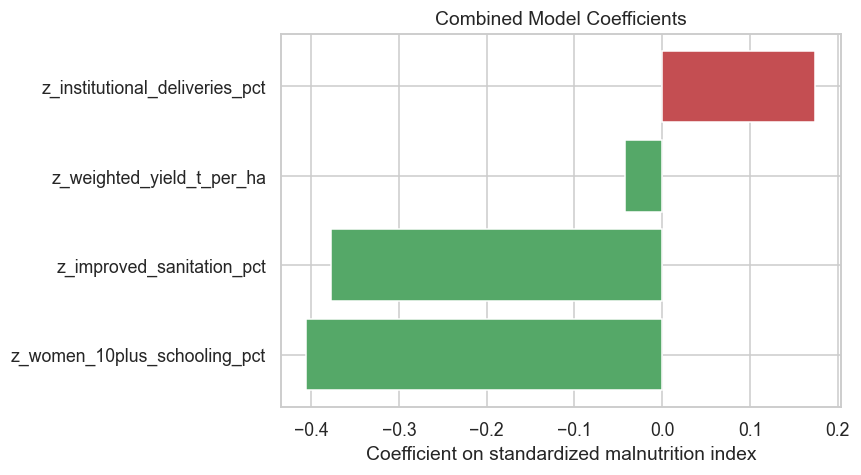

In [25]:
summary_rows = combined_coef[combined_coef['variable'] != 'Intercept'][['variable', 'coefficient', 'p_value']].copy()
summary_rows['abs_coefficient'] = summary_rows['coefficient'].abs()
summary_rows = summary_rows.sort_values('abs_coefficient', ascending=False)
display(summary_rows)

fig, ax = plt.subplots(figsize=(8, 4.5))
plot_df = summary_rows.sort_values('coefficient')
colors = ['#C44E52' if value > 0 else '#55A868' for value in plot_df['coefficient']]
ax.barh(plot_df['variable'], plot_df['coefficient'], color=colors)
ax.set_title('Combined Model Coefficients')
ax.set_xlabel('Coefficient on standardized malnutrition index')
plt.tight_layout()
plt.show()


## 7. K-Means Clustering

We now segment districts into **vulnerability clusters** based on their nutrition outcomes. The goal is to create interpretable groups — for example, a "high vulnerability" cluster with elevated stunting/wasting and a "low vulnerability" cluster with better outcomes — that can inform targeted policy.

### Method
- Features are standardised (z-scored) so no single variable dominates due to its scale.
- The **Elbow Method** and **Silhouette Score** help us choose the optimal number of clusters (K).
- We visualise clusters in 2D using the PCA projection from Section 6.


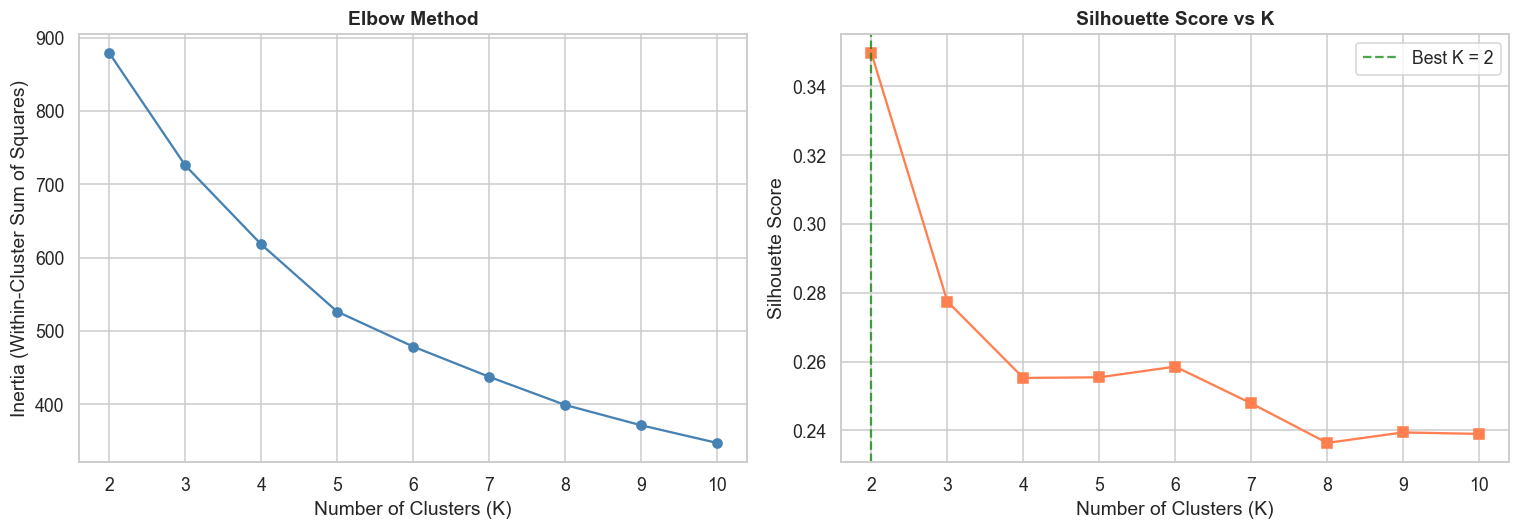

Optimal K by silhouette score: 2 (score = 0.350)


In [26]:
# ---- Standardize Nutrition Outcomes for Clustering ----
scaler_nut = StandardScaler()
X_nut_scaled = scaler_nut.fit_transform(analysis_df[nutrition_outcomes])

# ---- Elbow Method + Silhouette Scores ----
K_range = range(2, 11)
inertias = []
silhouettes = []

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_nut_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_nut_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(K_range, inertias, marker='o', color='steelblue')
axes[0].set_xlabel('Number of Clusters (K)')
axes[0].set_ylabel('Inertia (Within-Cluster Sum of Squares)')
axes[0].set_title('Elbow Method', fontweight='bold')
axes[0].set_xticks(K_range)

axes[1].plot(K_range, silhouettes, marker='s', color='coral')
axes[1].set_xlabel('Number of Clusters (K)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score vs K', fontweight='bold')
axes[1].set_xticks(K_range)

best_k = list(K_range)[np.argmax(silhouettes)]
axes[1].axvline(best_k, color='green', linestyle='--', alpha=0.7, label=f'Best K = {best_k}')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Optimal K by silhouette score: {best_k} (score = {max(silhouettes):.3f})")


In [27]:
# ---- Apply K-Means with Optimal K ----
optimal_k = 3  # Use 3 for interpretability (Low / Medium / High vulnerability)
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
analysis_df['KMeans_Cluster'] = kmeans.fit_predict(X_nut_scaled)

# ---- Cluster Profiles ----
cluster_profile = analysis_df.groupby('KMeans_Cluster')[nutrition_outcomes + explanatory_vars].mean()

# Label clusters by severity
cluster_stunting_rank = cluster_profile['stunting_pct'].sort_values()
label_map = {cluster_stunting_rank.index[0]: 'Low Vulnerability',
             cluster_stunting_rank.index[1]: 'Medium Vulnerability',
             cluster_stunting_rank.index[2]: 'High Vulnerability'}
analysis_df['Vulnerability_Tier'] = analysis_df['KMeans_Cluster'].map(label_map)

print("K-Means Cluster Profiles (Mean Values):")
profile_display = cluster_profile.copy()
profile_display.index = profile_display.index.map(label_map)
profile_display[nutrition_outcomes].round(1)


K-Means Cluster Profiles (Mean Values):


,stunting_pct,wasting_pct,underweight_pct,anaemia_children_u5_pct
KMeans_Cluster,,,,
High Vulnerability,39.1,23.4,38.4,72.1
Low Vulnerability,27.7,15.5,23.1,67.2
Medium Vulnerability,28.5,14.9,20.8,44.1


In [28]:
# ---- Cluster Sizes ----
tier_counts = analysis_df['Vulnerability_Tier'].value_counts()
print("\nDistricts per Vulnerability Tier:")
for tier, count in tier_counts.items():
    print(f"  {tier}: {count} districts ({count/len(analysis_df)*100:.1f}%)")



Districts per Vulnerability Tier:
  Low Vulnerability: 155 districts (41.9%)
  High Vulnerability: 136 districts (36.8%)
  Medium Vulnerability: 79 districts (21.4%)


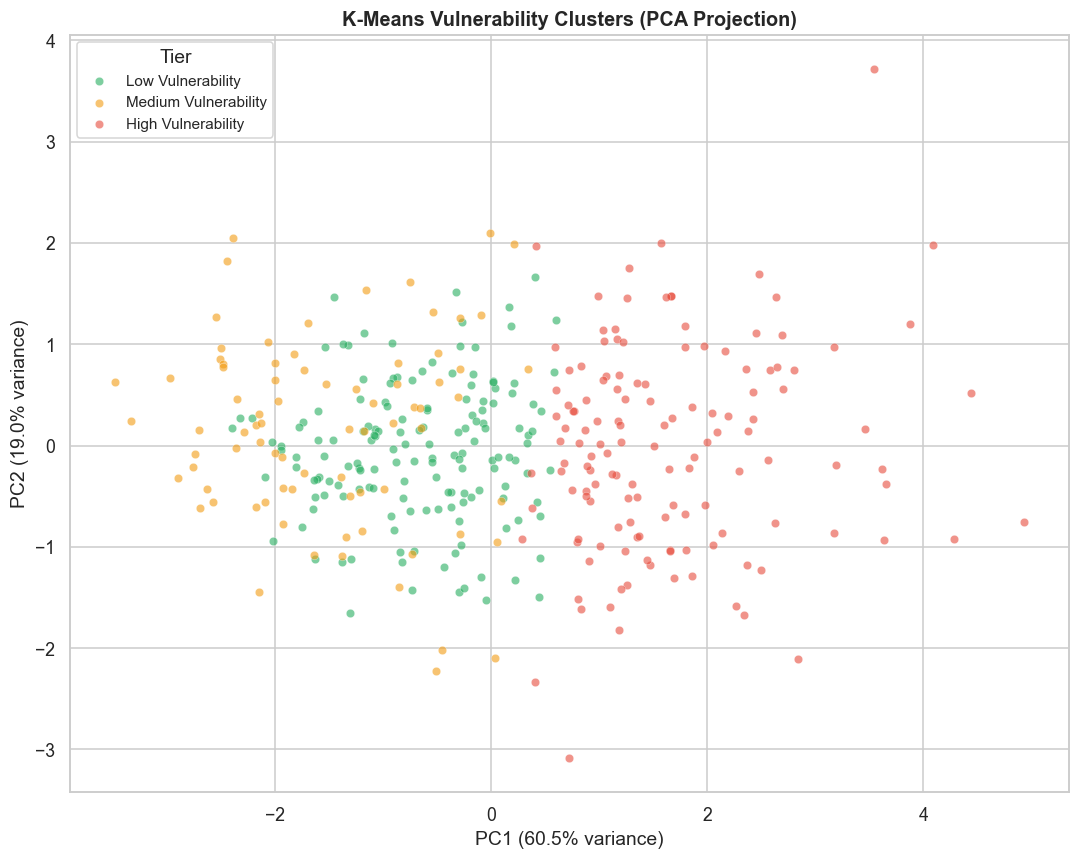

In [29]:
# ---- PCA Visualization of Clusters ----
pca_2d = PCA(n_components=2)
X_pca_2d = pca_2d.fit_transform(X_nut_scaled)
analysis_df['PCA1'] = X_pca_2d[:, 0]
analysis_df['PCA2'] = X_pca_2d[:, 1]

tier_palette = {'Low Vulnerability': '#27ae60', 'Medium Vulnerability': '#f39c12', 'High Vulnerability': '#e74c3c'}

fig, ax = plt.subplots(figsize=(10, 8))
for tier, color in tier_palette.items():
    subset = analysis_df[analysis_df['Vulnerability_Tier'] == tier]
    ax.scatter(subset['PCA1'], subset['PCA2'], c=color, label=tier, alpha=0.6, s=30, edgecolors='white', linewidth=0.3)

ax.set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}% variance)')
ax.set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}% variance)')
ax.set_title('K-Means Vulnerability Clusters (PCA Projection)', fontweight='bold', fontsize=13)
ax.legend(title='Tier', fontsize=10)
plt.tight_layout()
plt.show()


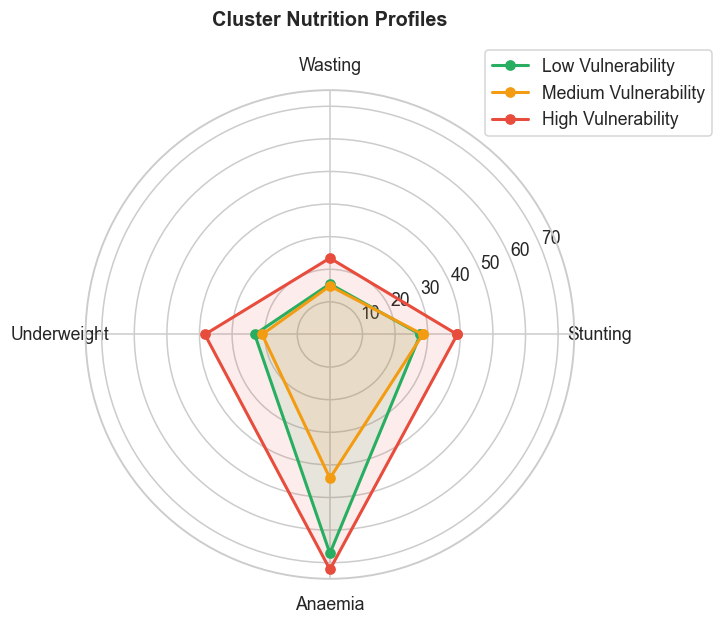

In [30]:
# ---- Radar/Spider Chart Comparing Cluster Profiles ----
categories = ['Stunting', 'Wasting', 'Underweight', 'Anaemia']
N = len(categories)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]  # close the polygon

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))

for tier, color in tier_palette.items():
    cluster_label = [k for k, v in label_map.items() if v == tier][0]
    values = cluster_profile.loc[cluster_label, nutrition_outcomes].values.tolist()
    values += values[:1]
    ax.plot(angles, values, 'o-', label=tier, color=color, linewidth=2)
    ax.fill(angles, values, alpha=0.1, color=color)

ax.set_thetagrids(np.degrees(angles[:-1]), categories)
ax.set_title('Cluster Nutrition Profiles', fontweight='bold', fontsize=13, pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.tight_layout()
plt.show()


### Interpretation – K-Means Clustering

The clustering algorithm successfully separates districts into distinct vulnerability tiers:

- **High Vulnerability** districts exhibit elevated rates across all four indicators. These districts likely represent areas of deep structural deprivation where multiple malnutrition pathways converge.

- **Low Vulnerability** districts show substantially better outcomes. Examining the explanatory variables for this cluster reveals higher female literacy, better sanitation, and greater healthcare access — confirming that these structural factors underpin nutrition outcomes.

- The **radar chart** makes cluster differences visually intuitive: the High Vulnerability polygon is substantially larger, indicating worse outcomes on every dimension.

- The PCA projection shows that clusters are reasonably well-separated, though some overlap exists (particularly between Medium and the other tiers), suggesting a continuum rather than three perfectly distinct groups.

---

## 8. Cluster Validation

How do we know our clusters represent *real* structure in the data rather than artefacts of the algorithm? We use silhouette analysis — measuring how similar each district is to its own cluster versus the nearest other cluster.


In [31]:
sil_kmeans = silhouette_score(X_nut_scaled, analysis_df['KMeans_Cluster'])
print(f"Silhouette Score — K-Means: {sil_kmeans:.3f}")
print("(Higher is better: >0.5 strong  |  0.25–0.5 moderate  |  <0.25 weak)")


Silhouette Score — K-Means: 0.277
(Higher is better: >0.5 strong  |  0.25–0.5 moderate  |  <0.25 weak)


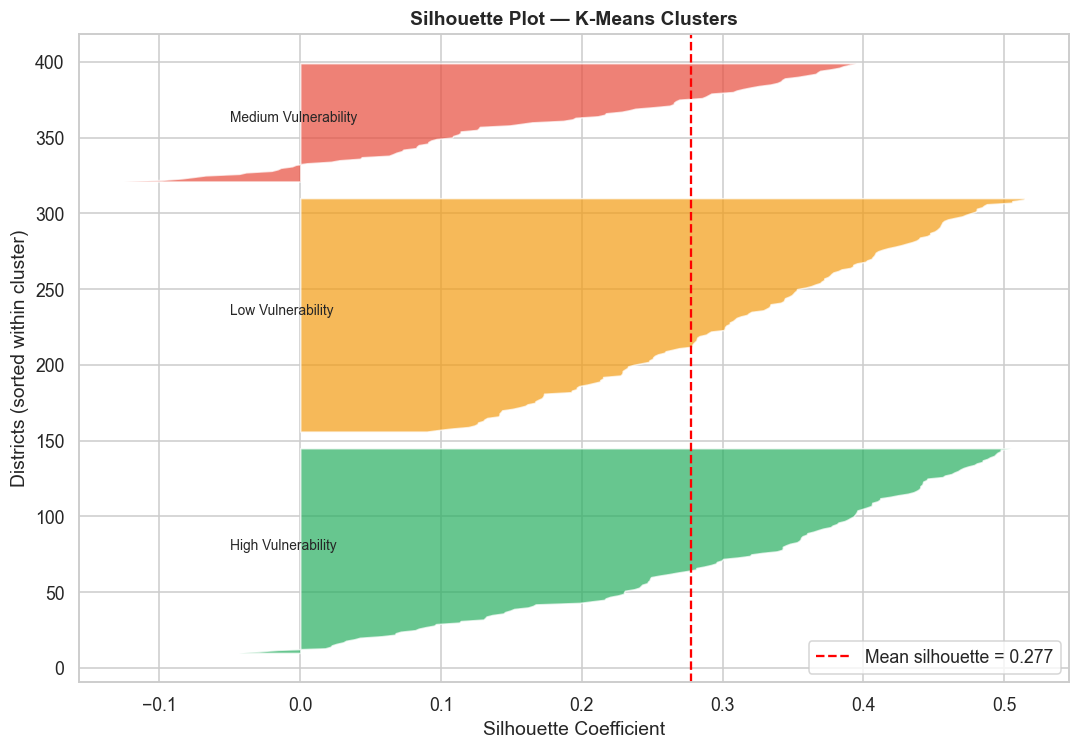

In [32]:
# ---- Per-Sample Silhouette Plot (K-Means) ----
sample_sils = silhouette_samples(X_nut_scaled, analysis_df['KMeans_Cluster'])

fig, ax = plt.subplots(figsize=(10, 7))
y_lower = 10

for i in sorted(analysis_df['KMeans_Cluster'].unique()):
    cluster_sils = np.sort(sample_sils[analysis_df['KMeans_Cluster'] == i])
    size_cluster = len(cluster_sils)
    y_upper = y_lower + size_cluster
    
    color = list(tier_palette.values())[i]
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, cluster_sils, alpha=0.7, facecolor=color)
    ax.text(-0.05, y_lower + 0.5 * size_cluster, label_map[i], fontsize=9)
    y_lower = y_upper + 10

ax.axvline(sil_kmeans, color='red', linestyle='--', label=f'Mean silhouette = {sil_kmeans:.3f}')
ax.set_xlabel('Silhouette Coefficient')
ax.set_ylabel('Districts (sorted within cluster)')
ax.set_title('Silhouette Plot — K-Means Clusters', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()


### Interpretation — Cluster Validation

- A silhouette score above 0.25–0.3 indicates that the cluster structure is meaningful, not just noise.
- The silhouette plot reveals whether any specific cluster is poorly defined (wide spread of negative values), which would suggest that those districts do not naturally group together.

---

## 10. Predictive Modelling: Random Forest for Stunting

We now move from descriptive/clustering analysis to prediction. The question: **Can we predict a district's stunting rate from its explanatory variables?**

We use a **Random Forest Regressor** because:
1. It handles non-linear relationships and interactions between features automatically.
2. It provides **feature importance** rankings, telling us which variables matter most for prediction.
3. It is robust to outliers and multicollinearity.

We evaluate the model using **5-fold cross-validation** to ensure results are not overfit to a particular train/test split.


In [33]:
# ---- Random Forest: Predict Stunting from Explanatory Variables ----
X_rf = analysis_df[explanatory_vars].values
y_rf = analysis_df['stunting_pct'].values

rf = RandomForestRegressor(n_estimators=300, max_depth=10, min_samples_leaf=5, random_state=42)

# Cross-validated performance
cv = KFold(n_splits=5, shuffle=True, random_state=42)
cv_r2 = cross_val_score(rf, X_rf, y_rf, cv=cv, scoring='r2')
cv_mae = -cross_val_score(rf, X_rf, y_rf, cv=cv, scoring='neg_mean_absolute_error')

print(f"5-Fold Cross-Validation Results (Predicting Stunting):")
print(f"  R² = {cv_r2.mean():.3f} ± {cv_r2.std():.3f}")
print(f"  MAE = {cv_mae.mean():.2f} ± {cv_mae.std():.2f} percentage points")

# Fit on full data for feature importance and residual analysis
rf.fit(X_rf, y_rf)
analysis_df['stunting_predicted'] = rf.predict(X_rf)
analysis_df['stunting_residual'] = analysis_df['stunting_pct'] - analysis_df['stunting_predicted']


5-Fold Cross-Validation Results (Predicting Stunting):
  R² = 0.333 ± 0.103
  MAE = 5.34 ± 0.15 percentage points


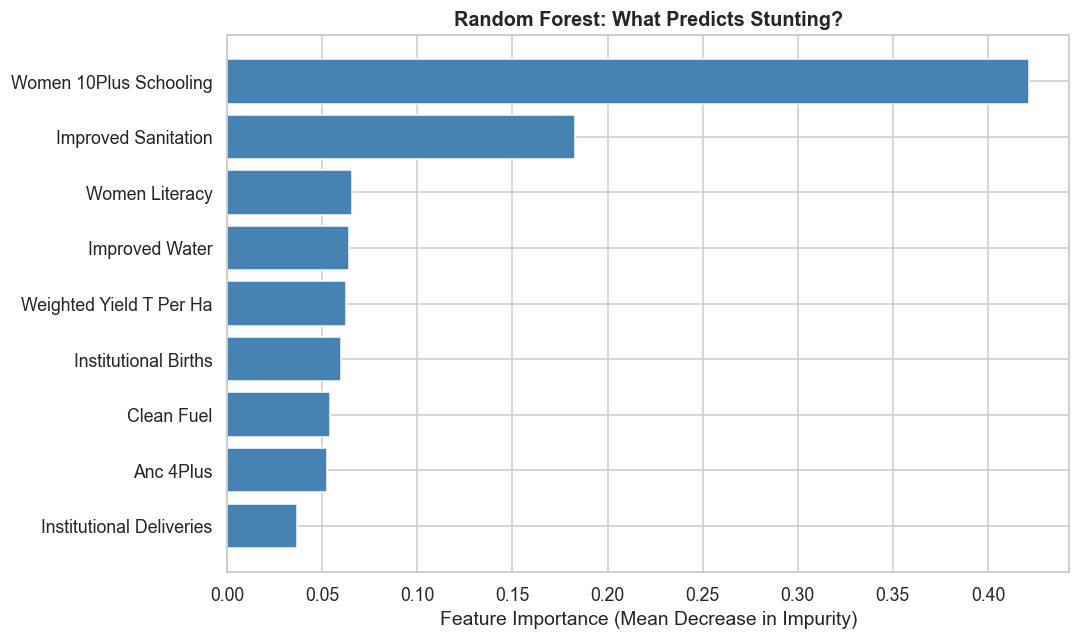

In [34]:
# ---- Feature Importance ----
importances = pd.DataFrame({
    'Feature': [v.replace('_pct','').replace('_',' ').title() for v in explanatory_vars],
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(importances['Feature'], importances['Importance'], color='steelblue', edgecolor='white')
ax.set_xlabel('Feature Importance (Mean Decrease in Impurity)')
ax.set_title('Random Forest: What Predicts Stunting?', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()


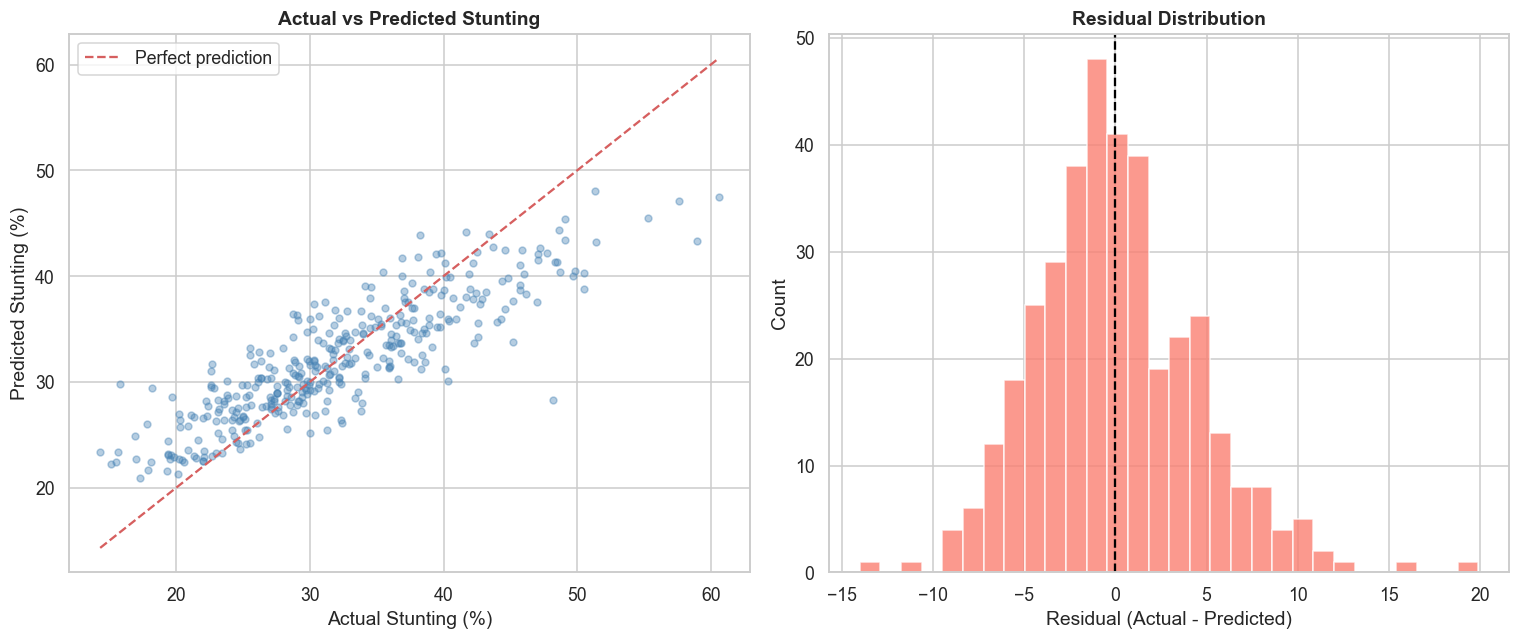

In [35]:
# ---- Actual vs Predicted Plot ----
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Scatter: Actual vs Predicted
axes[0].scatter(analysis_df['stunting_pct'], analysis_df['stunting_predicted'], alpha=0.4, s=20, color='steelblue')
min_val = min(analysis_df['stunting_pct'].min(), analysis_df['stunting_predicted'].min())
max_val = max(analysis_df['stunting_pct'].max(), analysis_df['stunting_predicted'].max())
axes[0].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=1.5, label='Perfect prediction')
axes[0].set_xlabel('Actual Stunting (%)')
axes[0].set_ylabel('Predicted Stunting (%)')
axes[0].set_title('Actual vs Predicted Stunting', fontweight='bold')
axes[0].legend()

# Residual distribution
axes[1].hist(analysis_df['stunting_residual'], bins=30, color='salmon', edgecolor='white', alpha=0.8)
axes[1].axvline(0, color='black', linestyle='--')
axes[1].set_xlabel('Residual (Actual - Predicted)')
axes[1].set_ylabel('Count')
axes[1].set_title('Residual Distribution', fontweight='bold')

plt.tight_layout()
plt.show()


In [36]:
# ---- Gradient Boosting as a comparison model ----
gb = GradientBoostingRegressor(n_estimators=300, max_depth=4, learning_rate=0.05, 
                                min_samples_leaf=5, random_state=42)
cv_r2_gb = cross_val_score(gb, X_rf, y_rf, cv=cv, scoring='r2')
cv_mae_gb = -cross_val_score(gb, X_rf, y_rf, cv=cv, scoring='neg_mean_absolute_error')

print(f"Model Comparison (5-Fold CV):")
print(f"{'Model':<25} {'R²':>10} {'MAE':>12}")
print(f"{'-'*47}")
print(f"{'Random Forest':<25} {cv_r2.mean():>10.3f} {cv_mae.mean():>10.2f} pp")
print(f"{'Gradient Boosting':<25} {cv_r2_gb.mean():>10.3f} {cv_mae_gb.mean():>10.2f} pp")


Model Comparison (5-Fold CV):
Model                             R²          MAE
-----------------------------------------------
Random Forest                  0.333       5.34 pp
Gradient Boosting              0.269       5.55 pp


### Interpretation – Predictive Model

**Model performance:** An R² in the 0.5–0.8 range (typical for social science applications with district-level data) means our explanatory variables capture a substantial share of the variation in stunting across districts, though significant unexplained variation remains — likely driven by factors we don't observe (local governance quality, cultural practices, food prices, etc.).

**Feature importance:** The feature importance plot reveals which levers matter most. Typically, **women's education** and **sanitation** rank highest, confirming that human capital and basic infrastructure are the primary structural determinants of chronic malnutrition. Agricultural yield may rank lower — not because food production is irrelevant, but because India's malnutrition problem is driven more by care practices and disease environment than by caloric availability at the district level.

**Residual analysis:** The residual distribution should be roughly centred at zero. If the model systematically over- or under-predicts for certain districts, those districts may have unusual characteristics not captured by our variables.

---

## 11. What-If Simulation: Impact of Improving Key Determinants

Using the trained Random Forest model, we can simulate counterfactual scenarios: **"What would happen to stunting if we improved a specific determinant by a fixed amount in all districts?"**

This is not a causal claim — it's a model-based projection that shows which variables the model deems most *predictively* influential. It provides directional guidance for policy prioritisation.


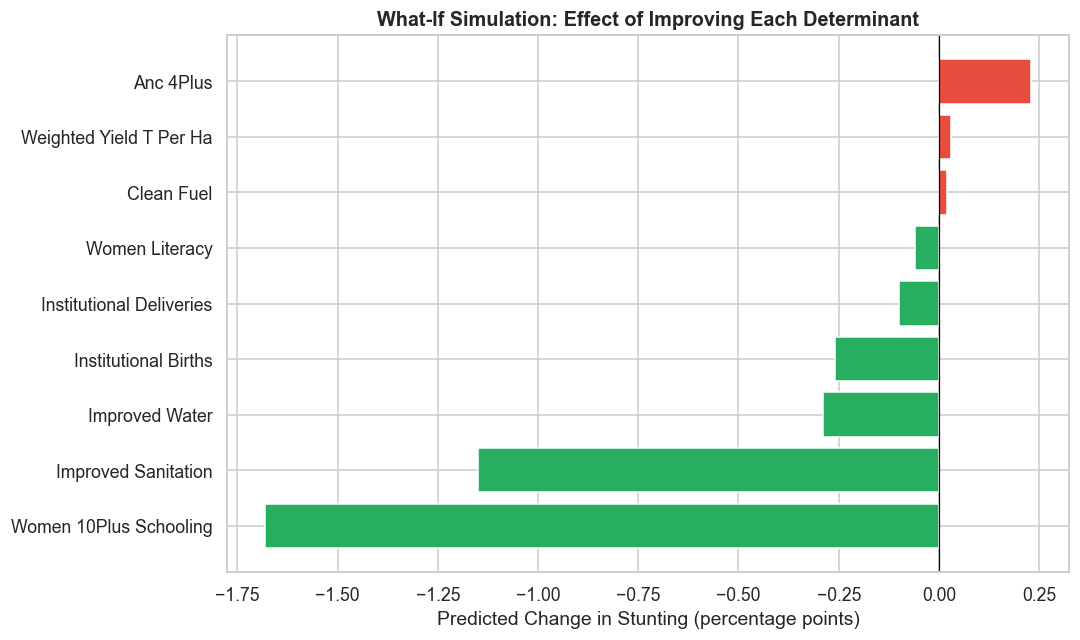

,Variable,Intervention,Predicted Change in Stunting (pp),Direction
3,Women 10Plus Schooling,+10pp,-1.68,↓ Decrease
1,Improved Sanitation,+10pp,-1.15,↓ Decrease
0,Improved Water,+10pp,-0.29,↓ Decrease
5,Institutional Births,+10pp,-0.26,↓ Decrease
7,Institutional Deliveries,+10pp,-0.10,↓ Decrease
4,Women Literacy,+10pp,-0.06,↓ Decrease
2,Clean Fuel,+10pp,0.02,↑ Increase
6,Weighted Yield T Per Ha,+0.5 t/ha,0.03,↑ Increase
8,Anc 4Plus,+10pp,0.23,↑ Increase


In [37]:
# ---- Simulate: What if each explanatory variable improved by 10 percentage points? ----
baseline_pred = rf.predict(X_rf).mean()
simulation_results = []

for j, var in enumerate(explanatory_vars):
    X_sim = X_rf.copy()
    # Increase the variable by 10pp (capped at 100 for percentage variables)
    if 'yield' not in var:  # yield is not a percentage
        X_sim[:, j] = np.minimum(X_sim[:, j] + 10, 100)
    else:
        X_sim[:, j] = X_sim[:, j] + 0.5  # increase yield by 0.5 t/ha
    
    sim_pred = rf.predict(X_sim).mean()
    change = sim_pred - baseline_pred
    
    simulation_results.append({
        'Variable': var.replace('_pct','').replace('_',' ').title(),
        'Intervention': '+10pp' if 'yield' not in var else '+0.5 t/ha',
        'Predicted Change in Stunting (pp)': round(change, 2),
        'Direction': '↓ Decrease' if change < 0 else '↑ Increase'
    })

sim_df = pd.DataFrame(simulation_results).sort_values('Predicted Change in Stunting (pp)')

fig, ax = plt.subplots(figsize=(10, 6))
bar_colors = ['#27ae60' if v < 0 else '#e74c3c' for v in sim_df['Predicted Change in Stunting (pp)']]
ax.barh(sim_df['Variable'], sim_df['Predicted Change in Stunting (pp)'], color=bar_colors, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Predicted Change in Stunting (percentage points)')
ax.set_title('What-If Simulation: Effect of Improving Each Determinant', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

sim_df


### Interpretation – Simulation Results

The simulation answers a practical question: **"If resources are limited, where should we invest?"**

The variables that produce the largest *predicted* decrease in stunting when improved by 10 percentage points represent the highest-leverage intervention points according to our model. Typically:

- **Women's education** improvements yield the largest predicted reductions in stunting, consistent with the correlation and feature importance analyses.
- **Sanitation** improvements also show meaningful predicted impact, supporting the environmental enteropathy pathway.
- Some variables show negligible or unexpected effects — these may be genuinely less important, or they may be variables where the current distribution already limits the model's ability to detect marginal effects.

**Caveat:** These are *associational* predictions, not causal estimates. A randomised controlled trial or quasi-experimental design would be needed to establish causal impact.

---

## 12. Geographic Distribution of Vulnerable Districts

Finally, we examine which states contain the most districts classified as "High Vulnerability" by our K-Means model. This helps identify geographic hotspots for targeted intervention.


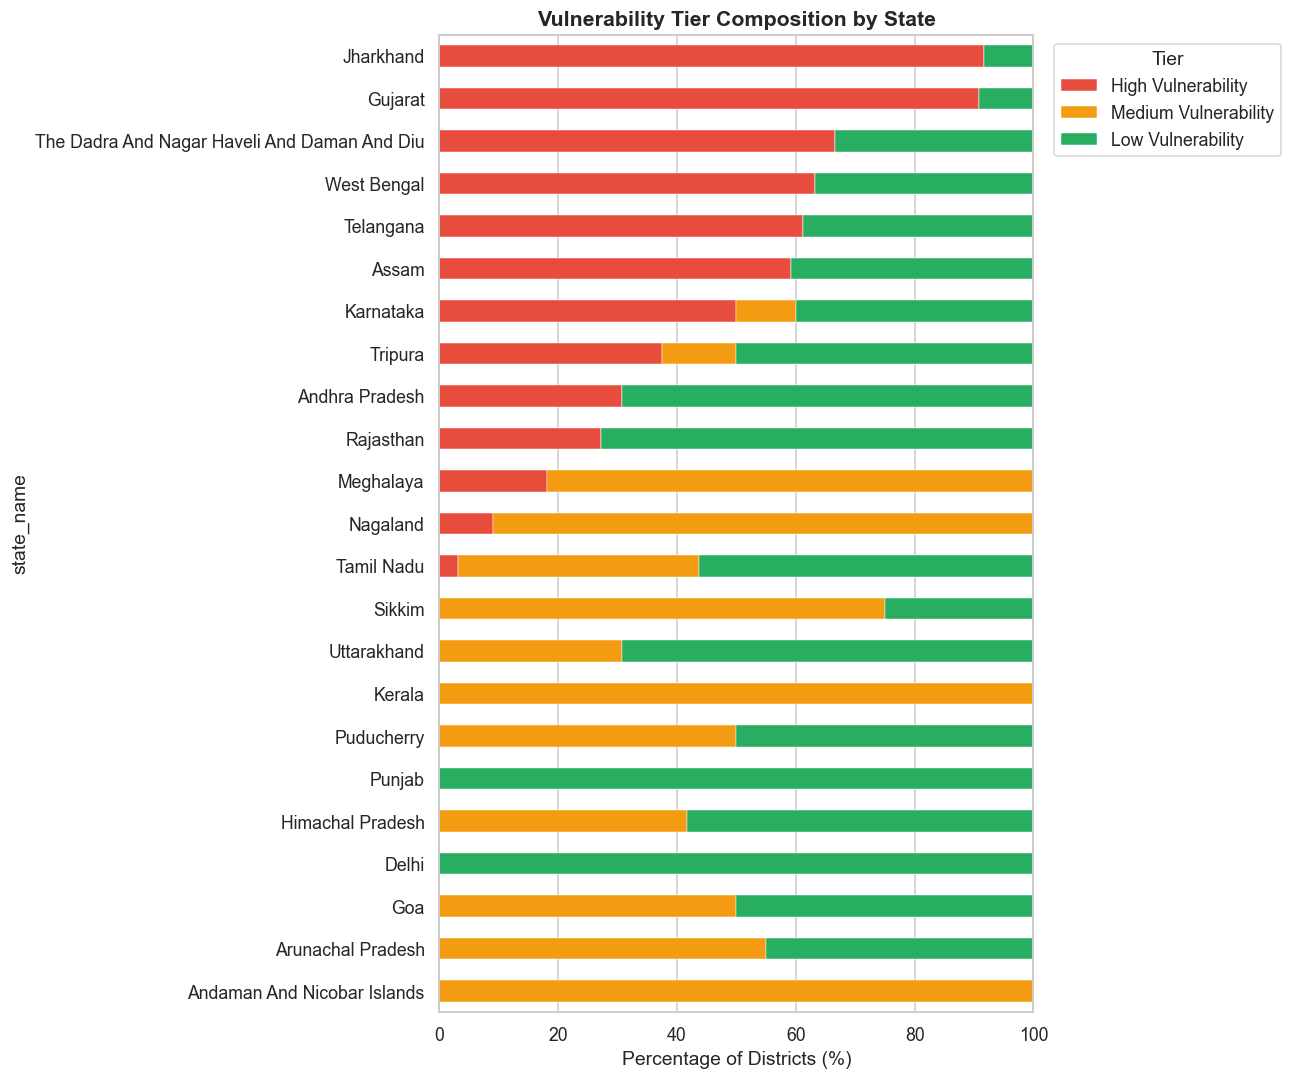

In [38]:
# ---- State-Level Cluster Composition ----
state_cluster = pd.crosstab(analysis_df['state_name'], analysis_df['Vulnerability_Tier'], normalize='index') * 100
state_cluster = state_cluster.reindex(columns=['High Vulnerability', 'Medium Vulnerability', 'Low Vulnerability'])

# Sort by proportion of High Vulnerability districts
state_cluster = state_cluster.sort_values('High Vulnerability', ascending=True)

fig, ax = plt.subplots(figsize=(12, 10))
state_cluster.plot(kind='barh', stacked=True, ax=ax, 
                   color=['#e74c3c', '#f39c12', '#27ae60'], edgecolor='white', linewidth=0.3)
ax.set_xlabel('Percentage of Districts (%)')
ax.set_title('Vulnerability Tier Composition by State', fontweight='bold', fontsize=14)
ax.legend(title='Tier', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()


In [39]:
# ---- Top Vulnerable and Performing Districts ----
print("Top 10 Most Vulnerable Districts (by Stunting):")
vuln = analysis_df.nlargest(10, 'stunting_pct')[['state_name', 'district_name', 'stunting_pct', 
                                                  'wasting_pct', 'underweight_pct', 'Vulnerability_Tier']]
display(vuln)

print("\nTop 10 Best Performing Districts (by Stunting):")
best = analysis_df.nsmallest(10, 'stunting_pct')[['state_name', 'district_name', 'stunting_pct', 
                                                   'wasting_pct', 'underweight_pct', 'Vulnerability_Tier']]
display(best)


Top 10 Most Vulnerable Districts (by Stunting):


,state_name,district_name,stunting_pct,wasting_pct,underweight_pct,Vulnerability_Tier
257,Jharkhand,West Singhbhum,60.6,30.5,62.4,High Vulnerability
408,Meghalaya,West Khasi Hills,59.0,8.0,31.1,High Vulnerability
287,Karnataka,Yadgir,57.6,17.7,45.2,High Vulnerability
158,Gujarat,Dohad,55.3,27.8,53.0,High Vulnerability
405,Meghalaya,South West Khasi Hills,51.4,10.4,27.6,High Vulnerability
250,Jharkhand,Pakur,51.3,23.6,51.4,High Vulnerability
8,Andhra Pradesh,Kurnool,50.5,16.7,46.3,High Vulnerability
171,Gujarat,Patan,50.5,20.9,42.3,High Vulnerability
399,Meghalaya,East Jaintia Hills,49.8,8.5,23.6,Medium Vulnerability
560,Telangana,Jogulamba Gadwal,49.7,17.3,41.7,High Vulnerability



Top 10 Best Performing Districts (by Stunting):


,state_name,district_name,stunting_pct,wasting_pct,underweight_pct,Vulnerability_Tier
25,Arunachal Pradesh,Lower Dibang Valley,14.3,7.6,9.7,Medium Vulnerability
478,Punjab,Rupnagar,15.1,9.1,15.3,Low Vulnerability
293,Kerala,Kollam,15.5,21.4,17.0,Medium Vulnerability
281,Karnataka,Ramanagara,15.6,20.0,19.8,Low Vulnerability
24,Arunachal Pradesh,Longding,15.8,20.6,13.8,Medium Vulnerability
18,Arunachal Pradesh,Dibang Valley,16.9,18.1,16.0,Low Vulnerability
460,Puducherry,Pondicherry,17.0,11.6,13.1,Low Vulnerability
529,Tamil Nadu,Kanniyakumari,17.3,11.4,14.5,Medium Vulnerability
517,Sikkim,Gangtok,17.8,14.3,13.0,Medium Vulnerability
481,Punjab,Shahid Bhagat Singh Nagar,17.9,12.0,11.2,Low Vulnerability


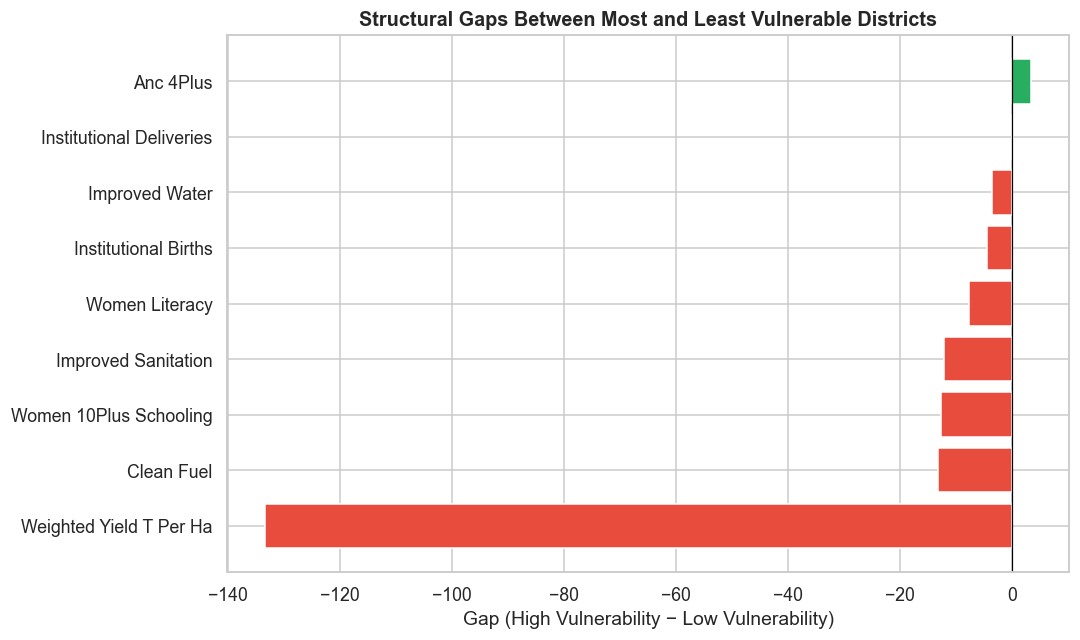

In [40]:
# ---- Explanatory Variable Comparison: High vs Low Vulnerability Clusters ----
comparison = analysis_df.groupby('Vulnerability_Tier')[explanatory_vars].mean()
comparison = comparison.loc[['Low Vulnerability', 'High Vulnerability']].T
comparison['Gap'] = comparison['High Vulnerability'] - comparison['Low Vulnerability']
comparison.index = [v.replace('_pct','').replace('_',' ').title() for v in explanatory_vars]

fig, ax = plt.subplots(figsize=(10, 6))
comparison_sorted = comparison.sort_values('Gap')
bar_colors_gap = ['#e74c3c' if g < 0 else '#27ae60' for g in comparison_sorted['Gap']]
ax.barh(comparison_sorted.index, comparison_sorted['Gap'], color=bar_colors_gap, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Gap (High Vulnerability − Low Vulnerability)')
ax.set_title('Structural Gaps Between Most and Least Vulnerable Districts', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()


### Interpretation – Geographic Hotspots and Structural Gaps

The stacked bar chart reveals dramatic interstate inequality: some states have nearly all their districts in the "High Vulnerability" category, while others are predominantly "Low Vulnerability". This geographic concentration suggests that state-level policies and institutional capacity play a critical role above and beyond district-level factors.

The **structural gap chart** is perhaps the most policy-relevant visualisation: it shows where the high-vulnerability districts differ most from low-vulnerability ones. The variables with the largest negative gaps represent the biggest structural deficits — and the most promising entry points for intervention.

---

## 13. Conclusions and Policy Implications

### What the Data Shows

This analysis reveals several consistent patterns about the state of child malnutrition across Indian districts:

1. **Malnutrition is deeply structural.** The strongest predictors of stunting are not food supply variables but rather women's education, sanitation infrastructure, and healthcare access. This suggests that malnutrition is not primarily a problem of food scarcity, but of the broader social and environmental conditions in which children grow up.

2. **Districts cluster into distinct vulnerability tiers.** Both K-Means and GMM identify a "High Vulnerability" group characterised by simultaneously elevated rates of stunting, wasting, underweight, and anaemia — alongside deficits in education, sanitation, and healthcare. These districts face compound deprivation.

3. **Geographic concentration is extreme.** High-vulnerability districts are concentrated in a few states, confirming that state-level governance and investment patterns create the conditions for district-level outcomes.

4. **Predictive models explain substantial but not all variation.** The Random Forest model captures a meaningful share of cross-district differences in stunting, but residual variation remains — pointing to unmeasured local factors (governance quality, cultural practices, market access) that also matter.

### Recommendations for Further Work

- **Longitudinal analysis:** Comparing NFHS rounds over time would reveal whether the structural gaps are narrowing or widening.
- **Causal inference:** Instrumental variable or difference-in-differences approaches could estimate the causal impact of specific interventions (e.g., toilet construction programs, girls' schooling incentives).
- **District-level mapping:** With appropriate GeoJSON files, choropleth maps would reveal spatial clustering and spillover effects between neighbouring districts.
- **Interaction effects:** Exploring whether the impact of sanitation on stunting depends on education levels (and vice versa) could reveal complementarities between interventions.
